# **PROYECTO FINAL - DATA SCIENCE III** 

**Carrera:** Data science  
**Estudainte:** Gonzalo Leonel Gramajo  
**Comisión:** 95480  
**Año:** 2025  
**Tema:** Análisis de titulares financieros con NLP y Deep Learning  

**Consigna:** 
La Entrega Final constará de dos partes: 
1. **NLP:** deberás entregar un dataset del estilo texto (libro, paper, documento, colección de tweets, etc) donde se desarrollen de mínima dos de las tareas más usuales de preprocesamiento de NLP. 
2. **Deep Learning:** debes construir tu primera red neuronal sencilla, lo que cubrirá la segunda actividad hacia la Entrega Final. 
*IMPORTANTE:*
Para la Entrega Final deberás elegir una de las dos actividades y profundizar en el mismo, ya sea realizando un análisis de texto sobre la actividad de NLP o mejorando la red, vía adición de capas, en el de Deep Learning.

## 1. Introducción

En este proyecto se integran dos áreas principales de la Ciencia de Datos:  
1. **NLP (Natural Language Processing):** análisis y preprocesamiento de titulares de noticias financieras.  
2. **Deep Learning:** construcción de una red neuronal para predecir el nivel de impacto de una noticia en el mercado (*Impact_Level*) a partir de texto y variables numéricas.  

## 2. Objetivos

- Realizar al menos dos tareas de preprocesamiento de NLP sobre el dataset.  
- Explorar el dataset y obtener insights relevantes.  
- Construir una red neuronal para predecir *Impact_Level*.  
- Comparar un modelo base con un modelo mejorado (más capas).  
- Reflexionar sobre los resultados y posibles aplicaciones.

**¿Por qué sería importante predecir Impact_Level?**  
Impact_Level representa la magnitud esperada de un evento en el mercado (bajo, medio, alto).  
Poder anticipar este nivel sería valioso para:  
- Gestión de riesgo → ajustar exposición si se espera un impacto alto.  
- Trading algorítmico → decidir tamaños de posición según riesgo esperado.  
- Alertas tempranas → priorizar noticias críticas sobre las de bajo impacto.

## 3. Descripción del Dataset

Está basado en un dataset rescatado de **Kaggle**:  
https://www.kaggle.com/datasets/pratyushpuri/financial-news-market-events-dataset-2025?select=financial_news_events.csv

Este conjunto de datos sintéticos contiene 3024 registros de titulares de noticias financieras centrados en los principales eventos del mercado desde febrero de 2025 hasta agosto de 2025. El conjunto de datos captura la dinámica del mercado en tiempo real, el análisis de sentimientos y los patrones comerciales en los mercados financieros globales, lo que lo hace ideal para tareas de análisis financiero, modelado de sentimientos y predicción del mercado.

Variables principales:  
- **Date**: fecha de la noticia  
- **Headline**: titular de la noticia  
- **Market_Event**: tipo de evento de mercado  
- **Market_Index**: índice bursátil afectado  
- **Index_Change_Percent**: variación porcentual  
- **Trading_Volume**: volumen de negociación  
- **Sentiment**: sentimiento asociado (Positive, Neutral, Negative)  
- **Sector**: sector económico  
- **Impact_Level**: nivel de impacto (Low, Medium, High)  
- **Related_Company**: empresa vinculada

## 4. Análisis Exploratorio de Datos (EDA)

### 4.1. Visión general del dataset
El objetivo de esta celda es:
- Cargar el CSV y normalizar tipos (fecha, numéricos).
- Ver estructura (`info()`), primeras/últimas filas (`head()`/`tail()`).
- Detectar valores faltantes y cardinalidad (cuántos valores únicos) por columna.

**Por qué esto primero:** antes de graficar, necesitamos saber **qué hay**, **en qué formato** está y **qué tan completo** está.

In [1]:
import pandas as pd # Pandas versión 1.5.3

# Ruta del archivo
CSV_PATH = "data/financial_news_events.csv"

# Opciones de display para que se vea mejor
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Cargar el dataset
# Notas:
# - Los datasets financieros usan coma como separador decimal.
# - Leemos como texto y luego convertimos columnas clave de forma robusta.
df_raw = pd.read_csv(CSV_PATH, dtype=str).apply(lambda col: col.str.strip() if col.dtype == "object" else col)

df = df_raw.copy()

# Info general
print("=== INFO GENERAL ===")
print(df.info(memory_usage="deep"))

print("\n=== HEAD (primeras 5) ===")
display(df.head(5))

print("\n=== TAIL (últimas 5) ===")
display(df.tail(5))

# Resumen estadístico mixto
print("\n=== DESCRIBE (numéricos y categóricas) ===")
display(df.describe(include="all"))

# Resumen específico para columnas datetime, si existen
for col in df.select_dtypes(include="datetime"):
    print(f"\nResumen de fechas para {col}:")
    print("  Mínimo:", df[col].min())
    print("  Máximo:", df[col].max())
    print("  Nº de valores válidos:", df[col].notna().sum())

# Valores faltantes (conteo y %)
na = df.isna().sum().to_frame("n_missing")
na["pct_missing"] = (na["n_missing"] / len(df) * 100).round(2)
print("\n=== FALTANTES ===")
display(na.sort_values("n_missing", ascending=False))

# Cardinalidad por columna
print("\n=== VALORES ÚNICOS POR COLUMNA ===")
display(df.nunique().sort_values(ascending=False).to_frame("n_unique"))

=== INFO GENERAL ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3024 entries, 0 to 3023
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Date                  3024 non-null   object
 1   Headline              2876 non-null   object
 2   Source                3024 non-null   object
 3   Market_Event          3024 non-null   object
 4   Market_Index          3024 non-null   object
 5   Index_Change_Percent  2863 non-null   object
 6   Trading_Volume        3024 non-null   object
 7   Sentiment             2853 non-null   object
 8   Sector                3024 non-null   object
 9   Impact_Level          3024 non-null   object
 10  Related_Company       3024 non-null   object
 11  News_Url              2871 non-null   object
dtypes: object(12)
memory usage: 2.3 MB
None

=== HEAD (primeras 5) ===


,Date,Headline,Source,Market_Event,Market_Index,Index_Change_Percent,Trading_Volume,Sentiment,Sector,Impact_Level,Related_Company,News_Url
0,2025-05-21,Nikkei 225 index benefits from a weaker yen,Times of India,Commodity Price Shock,DAX,3.52,166.45,NaN,Technology,High,Goldman Sachs,https://timesofindia.indiatimes.com/business/m...
1,2025-05-18,Government subsidy program gives a lift to the...,Financial Times,Central Bank Meeting,Shanghai Composite,-3.39,57.61,NaN,Retail,Low,ExxonMobil,https://timesofindia.indiatimes.com/business/m...
2,2025-06-25,New housing data release shows a slowdown in m...,The Hindu Business Line,Consumer Confidence Report,Shanghai Composite,-0.05,403.22,Neutral,Retail,Medium,Boeing,https://www.moneycontrol.com/us-markets/sp-500
3,2025-07-21,Massive stock buyback program announced by a c...,The Economist,Commodity Price Shock,NSE Nifty,-2.29,100.11,Positive,Consumer Goods,Low,Samsung Electronics,https://www.cnbc.com/2025/09/automotive-indust...
4,2025-07-23,Government spending bill is expected to stimul...,The Motley Fool,Inflation Data Release,Nasdaq Composite,-3.97,438.22,Negative,Consumer Goods,Low,JP Morgan Chase,https://www.bloomberg.com/australia/asx-200-pe...



=== TAIL (últimas 5) ===


,Date,Headline,Source,Market_Event,Market_Index,Index_Change_Percent,Trading_Volume,Sentiment,Sector,Impact_Level,Related_Company,News_Url
3019,2025-02-11,Tech Giant's New Product Launch Sparks Sector-...,The Motley Fool,Economic Data Release,DAX,-2.22,212.9,Neutral,Industrials,Low,Samsung Electronics,https://www.marketwatch.com/story/consumer-goo...
3020,2025-08-07,Government spending bill is expected to stimul...,Bloomberg,Geopolitical Event,Euro Stoxx 50,-0.17,105.88,Neutral,Aerospace & Defense,Low,Microsoft,https://www.ft.com/content/consumer-confidence...
3021,2025-05-22,Government spending bill is expected to stimul...,The Economist,Market Rally,Shanghai Composite,4.02,152.28,Negative,Telecommunications,Low,Samsung Electronics,https://www.reuters.com/markets/indices/ftse-100
3022,2025-07-17,Pharmaceutical company's drug approval drives ...,Forbes,Economic Data Release,CAC 40,0.12,53.49,Neutral,Healthcare,Medium,Goldman Sachs,https://www.business-standard.com/internationa...
3023,2025-03-07,Real Estate sector shows signs of overheating ...,Times of India,Interest Rate Change,Nasdaq Composite,-1.76,469.95,Negative,Automotive,Medium,Samsung Electronics,https://www.reuters.com/business/retail-sector...



=== DESCRIBE (numéricos y categóricas) ===


,Date,Headline,Source,Market_Event,Market_Index,Index_Change_Percent,Trading_Volume,Sentiment,Sector,Impact_Level,Related_Company,News_Url
count,3024,2876,3024,3024,3024,2863,3024,2853,3024,3024,3024,2871
unique,195,50,18,20,18,948,2914,3,18,3,10,50
top,2025-05-01,Automotive industry faces headwinds from risin...,Barron's,Market Rally,Dow Jones,-2.18,464.65,Negative,Transportation,Medium,Samsung Electronics,https://www.bloomberg.com/australia/asx-200-pe...
freq,26,82,197,183,198,8,3,974,184,1039,336,73



=== FALTANTES ===


,n_missing,pct_missing
Sentiment,171,5.65
Index_Change_Percent,161,5.32
News_Url,153,5.06
Headline,148,4.89
Market_Event,0,0.00
Source,0,0.00
Date,0,0.00
Market_Index,0,0.00
Trading_Volume,0,0.00
Sector,0,0.00



=== VALORES ÚNICOS POR COLUMNA ===


,n_unique
Trading_Volume,2914
Index_Change_Percent,948
Date,195
Headline,50
News_Url,50
Market_Event,20
Source,18
Market_Index,18
Sector,18
Related_Company,10


In [2]:
# Normalizamos nombres de columnas: sin espacios y en snake_case
df.columns = (df.columns
              .str.strip()
              .str.replace(r"\s+", "_", regex=True)
              .str.replace(r"[^0-9a-zA-Z_]", "", regex=True))

# Parseo de fecha
if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce", dayfirst=False)

# Helper para convertir texto con comas/ puntos a float
def to_float(series):
    s = series.astype(str).str.replace(r"[^\d,.\-]", "", regex=True)
    # Quita separadores de miles (.) y usa coma como decimal si existiera
    s = s.str.replace(".", "", regex=False).str.replace(",", ".", regex=False)
    return pd.to_numeric(s, errors="coerce")

# Convertimos numéricos clave si están presentes
for col in ["Index_Change_Percent", "Trading_Volume"]:
    if col in df.columns:
        df[col] = to_float(df[col])

# Estandarizamos categóricas clave (opcional): title-case o upper según prefieras
for col in ["Market_Event", "Market_Index", "Sentiment", "Sector", "Impact_Level", "Related_Company", "Source"]:
    if col in df.columns:
        df[col] = df[col].fillna("").str.strip()

# Info general
print("=== INFO GENERAL ===")
print(df.info(memory_usage="deep"))

print("\n=== HEAD (primeras 5) ===")
display(df.head(5))

print("\n=== TAIL (últimas 5) ===")
display(df.tail(5))

# Resumen estadístico mixto
print("\n=== DESCRIBE (numéricos y categóricas) ===")
display(df.describe(include="all"))

# Valores faltantes (conteo y %)
na = df.isna().sum().to_frame("n_missing")
na["pct_missing"] = (na["n_missing"] / len(df) * 100).round(2)
print("\n=== FALTANTES ===")
display(na.sort_values("n_missing", ascending=False))

# Cardinalidad por columna
print("\n=== VALORES ÚNICOS POR COLUMNA ===")
display(df.nunique().sort_values(ascending=False).to_frame("n_unique"))


=== INFO GENERAL ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3024 entries, 0 to 3023
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date                  3024 non-null   datetime64[ns]
 1   Headline              2876 non-null   object        
 2   Source                3024 non-null   object        
 3   Market_Event          3024 non-null   object        
 4   Market_Index          3024 non-null   object        
 5   Index_Change_Percent  2863 non-null   float64       
 6   Trading_Volume        3024 non-null   int64         
 7   Sentiment             3024 non-null   object        
 8   Sector                3024 non-null   object        
 9   Impact_Level          3024 non-null   object        
 10  Related_Company       3024 non-null   object        
 11  News_Url              2871 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(9)
m

,Date,Headline,Source,Market_Event,Market_Index,Index_Change_Percent,Trading_Volume,Sentiment,Sector,Impact_Level,Related_Company,News_Url
0,2025-05-21,Nikkei 225 index benefits from a weaker yen,Times of India,Commodity Price Shock,DAX,352.0,16645,,Technology,High,Goldman Sachs,https://timesofindia.indiatimes.com/business/m...
1,2025-05-18,Government subsidy program gives a lift to the...,Financial Times,Central Bank Meeting,Shanghai Composite,-339.0,5761,,Retail,Low,ExxonMobil,https://timesofindia.indiatimes.com/business/m...
2,2025-06-25,New housing data release shows a slowdown in m...,The Hindu Business Line,Consumer Confidence Report,Shanghai Composite,-5.0,40322,Neutral,Retail,Medium,Boeing,https://www.moneycontrol.com/us-markets/sp-500
3,2025-07-21,Massive stock buyback program announced by a c...,The Economist,Commodity Price Shock,NSE Nifty,-229.0,10011,Positive,Consumer Goods,Low,Samsung Electronics,https://www.cnbc.com/2025/09/automotive-indust...
4,2025-07-23,Government spending bill is expected to stimul...,The Motley Fool,Inflation Data Release,Nasdaq Composite,-397.0,43822,Negative,Consumer Goods,Low,JP Morgan Chase,https://www.bloomberg.com/australia/asx-200-pe...



=== TAIL (últimas 5) ===


,Date,Headline,Source,Market_Event,Market_Index,Index_Change_Percent,Trading_Volume,Sentiment,Sector,Impact_Level,Related_Company,News_Url
3019,2025-02-11,Tech Giant's New Product Launch Sparks Sector-...,The Motley Fool,Economic Data Release,DAX,-222.0,2129,Neutral,Industrials,Low,Samsung Electronics,https://www.marketwatch.com/story/consumer-goo...
3020,2025-08-07,Government spending bill is expected to stimul...,Bloomberg,Geopolitical Event,Euro Stoxx 50,-17.0,10588,Neutral,Aerospace & Defense,Low,Microsoft,https://www.ft.com/content/consumer-confidence...
3021,2025-05-22,Government spending bill is expected to stimul...,The Economist,Market Rally,Shanghai Composite,402.0,15228,Negative,Telecommunications,Low,Samsung Electronics,https://www.reuters.com/markets/indices/ftse-100
3022,2025-07-17,Pharmaceutical company's drug approval drives ...,Forbes,Economic Data Release,CAC 40,12.0,5349,Neutral,Healthcare,Medium,Goldman Sachs,https://www.business-standard.com/internationa...
3023,2025-03-07,Real Estate sector shows signs of overheating ...,Times of India,Interest Rate Change,Nasdaq Composite,-176.0,46995,Negative,Automotive,Medium,Samsung Electronics,https://www.reuters.com/business/retail-sector...



=== DESCRIBE (numéricos y categóricas) ===


,Date,Headline,Source,Market_Event,Market_Index,Index_Change_Percent,Trading_Volume,Sentiment,Sector,Impact_Level,Related_Company,News_Url
count,3024,2876,3024,3024,3024,2863.000000,3024.000000,3024,3024,3024,3024,2871
unique,NaN,50,18,20,18,NaN,NaN,4,18,3,10,50
top,NaN,Automotive industry faces headwinds from risin...,Barron's,Market Rally,Dow Jones,NaN,NaN,Negative,Transportation,Medium,Samsung Electronics,https://www.bloomberg.com/australia/asx-200-pe...
freq,NaN,82,197,183,198,NaN,NaN,974,184,1039,336,73
mean,2025-05-09 07:43:48.571428608,NaN,NaN,NaN,NaN,0.524974,22737.321429,NaN,NaN,NaN,NaN,NaN
min,2025-02-01 00:00:00,NaN,NaN,NaN,NaN,-499.000000,16.000000,NaN,NaN,NaN,NaN,NaN
25%,2025-03-23 00:00:00,NaN,NaN,NaN,NaN,-216.000000,8438.000000,NaN,NaN,NaN,NaN,NaN
50%,2025-05-09 00:00:00,NaN,NaN,NaN,NaN,-5.000000,21716.000000,NaN,NaN,NaN,NaN,NaN
75%,2025-06-26 00:00:00,NaN,NaN,NaN,NaN,225.000000,36241.000000,NaN,NaN,NaN,NaN,NaN
max,2025-08-14 00:00:00,NaN,NaN,NaN,NaN,499.000000,49983.000000,NaN,NaN,NaN,NaN,NaN



=== FALTANTES ===


,n_missing,pct_missing
Index_Change_Percent,161,5.32
News_Url,153,5.06
Headline,148,4.89
Date,0,0.00
Market_Event,0,0.00
Source,0,0.00
Trading_Volume,0,0.00
Market_Index,0,0.00
Sentiment,0,0.00
Sector,0,0.00



=== VALORES ÚNICOS POR COLUMNA ===


,n_unique
Trading_Volume,2895
Index_Change_Percent,866
Date,195
Headline,50
News_Url,50
Market_Event,20
Source,18
Market_Index,18
Sector,18
Related_Company,10


### 4.2. Tratamiento de datos faltantes   
Teniendo en cuenta el primer análisis de los datos, de decide lo siguiente:
- Eliminar filas con Headline nulo, porque este valor es esencial para el objetivo de lograr un modelo de NLP.  
- Eliminar columna News_URL, porque no es relevante para el trabajo a realizar.   
- Imputar Index_Change_Percent con la mediana, ya que no son muchos y es útil para la parte de Deep Learning.  

In [3]:
# 1) Drop columna que no sirve
if "News_Url" in df.columns:
    df.drop(columns=["News_Url"], inplace=True)

# 2) Eliminar filas sin Headline
df = df[df["Headline"].notna()]

# 3) Imputar Index_Change_Percent con la mediana
if "Index_Change_Percent" in df.columns:
    median_val = df["Index_Change_Percent"].median()
    df["Index_Change_Percent"] = df["Index_Change_Percent"].fillna(median_val)

print("Después de limpieza:", df.shape)
print("Faltantes restantes:\n", df.isna().sum())


Después de limpieza: (2876, 11)
Faltantes restantes:
 Date                    0
Headline                0
Source                  0
Market_Event            0
Market_Index            0
Index_Change_Percent    0
Trading_Volume          0
Sentiment               0
Sector                  0
Impact_Level            0
Related_Company         0
dtype: int64


### 4.3 Análisis de outliers en *Index_Change_Percent* y *Trading_Volume*

En esta sección buscamos:
- Detectar la presencia de **outliers** (valores extremos) en las variables numéricas clave.
- Comprender si esos valores son errores de carga o parte natural del comportamiento de los datos financieros.

**Criterio:**
- En finanzas, outliers son comunes (picos en volumen de operaciones, caídas abruptas de índices).  
- No siempre deben eliminarse: a veces representan precisamente los eventos más relevantes.  
- Vamos a usar:
  - **Boxplots**: para ver valores alejados de la mediana.
  - **Reglas estadísticas**: rango intercuartílico (IQR) para cuantificar cuántos outliers hay.
  - **Histogramas/log-transform**: útil en variables muy asimétricas (ej. Trading_Volume).


Index_Change_Percent:
  Q1=-203.00, Q3=212.00, IQR=415.00
  Límites: [-825.50, 834.50]
  Outliers detectados: 0 (0.0%)


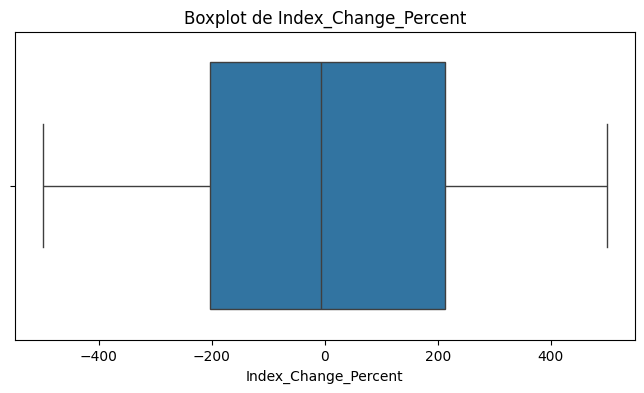

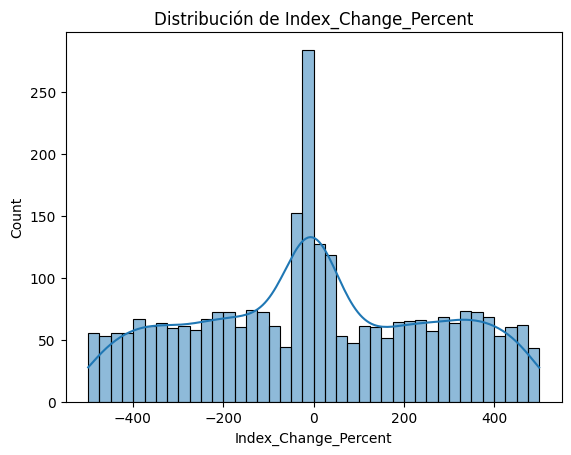


Trading_Volume:
  Q1=8478.50, Q3=36470.00, IQR=27991.50
  Límites: [-33508.75, 78457.25]
  Outliers detectados: 0 (0.0%)


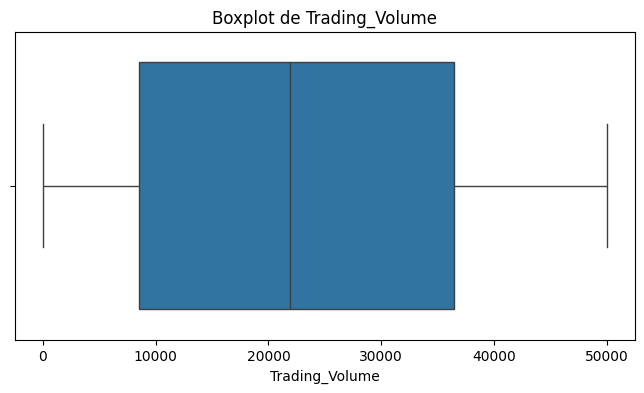

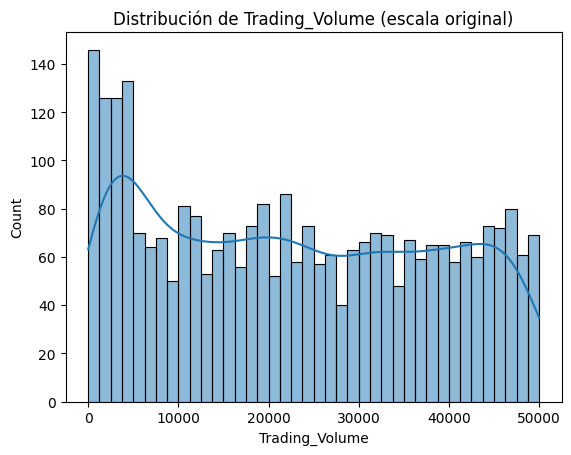

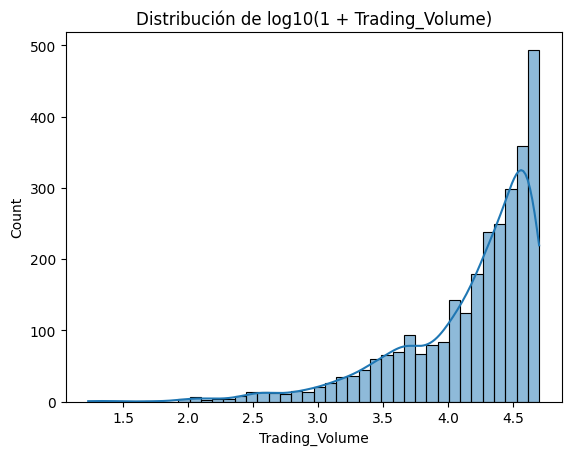

In [4]:
# --- 4.3 Análisis de outliers -----------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Función auxiliar: detectar outliers con IQR
def outlier_stats(series, name="var"):
    """
    Calcula rango intercuartílico (IQR) y detecta outliers.
    """
    s = series.dropna()
    Q1, Q3 = np.percentile(s, [25, 75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_outliers = ((s < lower) | (s > upper)).sum()
    pct_outliers = n_outliers / len(s) * 100
    print(f"\n{name}:")
    print(f"  Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
    print(f"  Límites: [{lower:.2f}, {upper:.2f}]")
    print(f"  Outliers detectados: {n_outliers} ({pct_outliers:.1f}%)")

# 1) Index_Change_Percent
if "Index_Change_Percent" in df.columns:
    outlier_stats(df["Index_Change_Percent"], "Index_Change_Percent")
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df["Index_Change_Percent"])
    plt.title("Boxplot de Index_Change_Percent")
    plt.show()
    
    sns.histplot(df["Index_Change_Percent"], bins=40, kde=True)
    plt.title("Distribución de Index_Change_Percent")
    plt.show()

# 2) Trading_Volume
if "Trading_Volume" in df.columns:
    outlier_stats(df["Trading_Volume"], "Trading_Volume")
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df["Trading_Volume"])
    plt.title("Boxplot de Trading_Volume")
    plt.show()
    
    sns.histplot(df["Trading_Volume"], bins=40, kde=True)
    plt.title("Distribución de Trading_Volume (escala original)")
    plt.show()
    
    # Como suele ser muy asimétrica → probar en log10
    vol_log = np.log10(1 + df["Trading_Volume"])
    sns.histplot(vol_log, bins=40, kde=True)
    plt.title("Distribución de log10(1 + Trading_Volume)")
    plt.show()


**Conclusiones de los gráficos y parámetros obtenidos:**

*Index_Change_Percent*
- El boxplot muestra que la mayoría de los valores están distribuidos alrededor de 0, con un rango entre aprox. -4000 y +4000.
- El histograma confirma que hay una fuerte concentración en valores cercanos a 0, pero también una dispersión amplia en ambos extremos.
- Según la regla del IQR, **no se detectaron outliers**: todos los valores se encuentran dentro de los límites esperados.
- Interpretación: aunque visualmente parece haber valores extremos, en realidad corresponden a la variabilidad natural de cambios porcentuales en índices bursátiles.  
  Esto refleja bien la volatilidad del mercado.

*Trading_Volume*
- El boxplot indica que los volúmenes se distribuyen en un rango amplio, entre ~0 y 50.000.
- El histograma en escala original muestra una concentración de casos en volúmenes bajos y una dispersión hacia valores más altos.
- Al aplicar la transformación logarítmica `log10(1 + Trading_Volume)` la distribución se estabiliza, revelando una forma más “regular” y menos sesgada.
- Según el IQR, **no se detectaron outliers**.
- Interpretación: no es estrictamente necesario transformar la variable para entrenar un modelo, pero la versión logarítmica podría ayudar a estabilizar el entrenamiento en redes neuronales.  

*Conclusión general*
- No existen outliers “problemáticos” en estas variables, lo que simplifica el preprocesamiento.
- La dispersión observada es propia de datos financieros: caídas o subidas abruptas, y operaciones con distintos volúmenes.
- Para el modelado, se va a trabajar con las variables tal como están y también con la versión logarítmica de *Trading_Volume*. Esto es porque un gran movimiento del volumne, significa que la noticia impacta más fuertemente en el mercado, por lo que es buena opcion probar si de esta manera se obtiene un mejor **accuracy**.


### 4.4 Gráficos de barras por *Sector* y *Market_Event*

Objetivo: 
- Analizar la distribución de los **sectores económicos** y los **eventos de mercado** que aparecen en el dataset.
- Entender cuáles son más frecuentes y si existe un desbalance fuerte.

**Criterio:**
- Usamos gráficos de barras (countplot) porque ambas son variables categóricas.
- Si la cardinalidad es muy alta (muchos valores diferentes), mostramos solo el **Top-N** categorías más frecuentes para no perder legibilidad.

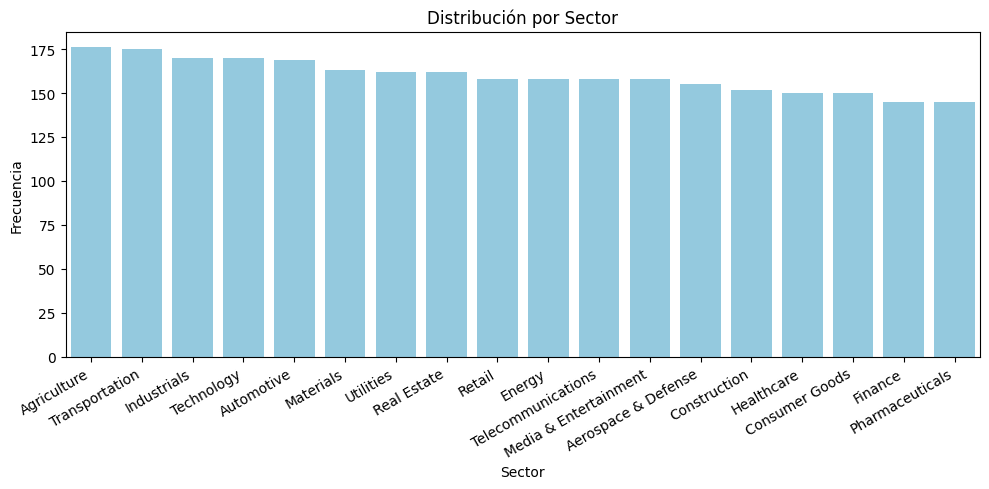

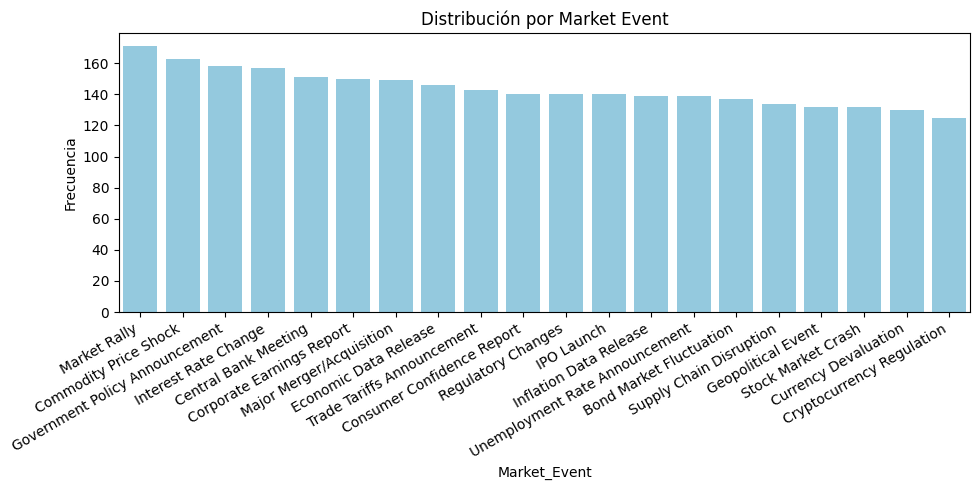

In [5]:
# --- 4.4 Gráficos de barras por Sector y Market_Event ------------------------
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)

def plot_top_categories(df, col, top_n, title):
    """
    Gráfico de barras para las categorías más frecuentes de una columna.
    - col: nombre de la columna categórica
    - top_n: número de categorías a mostrar
    """
    counts = df[col].value_counts().head(top_n)
    ax = sns.barplot(x=counts.index, y=counts.values, color="skyblue")
    ax.set_title(title or f"Distribución de {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frecuencia")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

# 1) Sector
if "Sector" in df.columns:
    plot_top_categories(df, "Sector", top_n=18, title="Distribución por Sector")

# 2) Market_Event
if "Market_Event" in df.columns:
    plot_top_categories(df, "Market_Event", top_n=20, title="Distribución por Market Event")


**Interpretación de los gráficos:**
- Estos gráficos permiten ver si hay **sectores dominantes** y si el dataset está desbalanceado. Como se puede observar, no se ve un gran desvalance.
- Lo mismo aplica para *Market_Event*: algunos tipos de eventos (inflación, política monetaria, lanzamientos de productos) podrían aparecer mucho más que otros. Tampoco se observa un gran desvalance.
- Dado que en ambos casos, el desvalance no es grande y se tiene una gran cantidad de categorías (18 y 20 respectivamente) se agregarían unas 38 columnas más al dataframe.

**Conclusión:**  
Se optará por no tener en cuenta estas variables al momento de realizar la parte de Deep Learning, debido a que se tendría mucho ruido para la cantidad de datos que son.   
Inflar la dimensionalidad va a dar más parámetros para el entrenamiento y con eso más riesgo de overfiting.

## 5. Preprocesamiento de NLP

### 5.1 Conversión de texto a minúsculas

El primer paso en el preprocesamiento de texto es **normalizar las palabras** para que no existan diferencias entre:
- "Economy" y "economy"
- "GOVERNMENT" y "government"

La conversión a minúsculas ayuda a **reducir la dimensionalidad** del vocabulario y facilita tareas posteriores como la tokenización y la lematización.

Este paso no altera el significado del texto, solo lo estandariza.


In [6]:
# Creamos una copia para no perder la columna original
df["headline_clean"] = df["Headline"].astype(str).str.lower()

# Visualizamos antes y después
print("ANTES:")
print(df["Headline"].head(10).to_list())

print("\nDESPUÉS (minúsculas):")
print(df["headline_clean"].head(10).to_list())


ANTES:
['Nikkei 225 index benefits from a weaker yen', 'Government subsidy program gives a lift to the agriculture sector', 'New housing data release shows a slowdown in market activity', 'Massive stock buyback program announced by a consumer goods company', 'Government spending bill is expected to stimulate the economy', 'Central bank maintains status quo on interest rates', "Tech Giant's New Product Launch Sparks Sector-Wide Gains", "A massive data breach sends a tech company's stock tumbling", 'Market sentiment turns positive on vaccine trial results', 'Global trade talks collapse, causing market turmoil']

DESPUÉS (minúsculas):
['nikkei 225 index benefits from a weaker yen', 'government subsidy program gives a lift to the agriculture sector', 'new housing data release shows a slowdown in market activity', 'massive stock buyback program announced by a consumer goods company', 'government spending bill is expected to stimulate the economy', 'central bank maintains status quo on inter

### 5.2 Tokenización

La **tokenización** consiste en dividir un texto en unidades mínimas llamadas *tokens*.  
En este caso, cada token será una **palabra** del titular.  

Ejemplo:  
- Texto original: `"Government Subsidy Program Gives a Lift"`  
- Tokens: `["government", "subsidy", "program", "gives", "a", "lift"]`

Este paso es fundamental porque:
- Permite contar frecuencias de palabras.  
- Facilita eliminar *stopwords* y aplicar lematización.  
- Es la base para representaciones vectoriales como Bag-of-Words o TF-IDF.

In [7]:
#NOTA: Antes de ejecutar esta celda, asegúrate de tener spaCy instalado y el modelo en inglés descargado:
# pip install spacy
# python -m spacy download en_core_web_sm

import spacy

# Cargamos modelo en inglés
nlp = spacy.load("en_core_web_sm")

# Función de tokenización con spaCy
def spacy_tokenizer(text):
    return [token.text for token in nlp(text)]

df["tokens_spacy"] = df["headline_clean"].apply(spacy_tokenizer)

# Ejemplo
print("Ejemplo de tokenización con spaCy:")
print(df[["headline_clean", "tokens_spacy"]].head(3))


Ejemplo de tokenización con spaCy:
                                      headline_clean                                       tokens_spacy
0        nikkei 225 index benefits from a weaker yen  [nikkei, 225, index, benefits, from, a, weaker...
1  government subsidy program gives a lift to the...  [government, subsidy, program, gives, a, lift,...
2  new housing data release shows a slowdown in m...  [new, housing, data, release, shows, a, slowdo...


### 5.3 Remoción de Stopwords

Las **stopwords** son palabras muy frecuentes en un idioma que, en la mayoría de los casos, no aportan valor semántico al análisis.  
Ejemplos en inglés: *"the"*, *"and"*, *"from"*, *"to"*.  

Al eliminarlas:
- Reducimos el ruido en el dataset.  
- Destacamos las palabras más relevantes de los titulares.  

En nuestro caso usamos **spaCy**, que trae listas de stopwords listas para inglés.

In [8]:
import spacy

# Cargar modelo en inglés
nlp = spacy.load("en_core_web_sm")

# Función para remover stopwords
def remove_stopwords(text):
    doc = nlp(text)
    return [token.text for token in doc if not token.is_stop and token.is_alpha]

# 🔎 NOTA:
# token.is_stop → filtra palabras que spaCy identifica como stopwords.
# token.is_alpha → mantiene solo palabras con caracteres alfabéticos (evita números o signos de puntuación).

# Aplicamos la limpieza a la columna de titulares
df["tokens_nostop"] = df["headline_clean"].apply(remove_stopwords)

# Ejemplo de comparación
for i in range(5):
    print(f"Titular original: {df['Headline'].iloc[i]}")
    print(f"Tokens sin stopwords: {df['tokens_nostop'].iloc[i]}")
    print("-"*60)

Titular original: Nikkei 225 index benefits from a weaker yen
Tokens sin stopwords: ['nikkei', 'index', 'benefits', 'weaker', 'yen']
------------------------------------------------------------
Titular original: Government subsidy program gives a lift to the agriculture sector
Tokens sin stopwords: ['government', 'subsidy', 'program', 'gives', 'lift', 'agriculture', 'sector']
------------------------------------------------------------
Titular original: New housing data release shows a slowdown in market activity
Tokens sin stopwords: ['new', 'housing', 'data', 'release', 'shows', 'slowdown', 'market', 'activity']
------------------------------------------------------------
Titular original: Massive stock buyback program announced by a consumer goods company
Tokens sin stopwords: ['massive', 'stock', 'buyback', 'program', 'announced', 'consumer', 'goods', 'company']
------------------------------------------------------------
Titular original: Government spending bill is expected to st

### 5.4 Lematización

La **lematización** reduce cada palabra a su **forma canónica** (*lemma*).  
Ejemplos:
- *“benefits”, “benefited”, “benefiting”* → **benefit**
- *“companies”, “company”* → **company**

**¿Por qué lematizar?**
- Reduce la **variabilidad** del vocabulario sin perder significado.
- Mejora las representaciones (BoW/TF-IDF) y suele ayudar a los modelos.

En este paso:
1) Obtenemos los **lemmas** (formas base).  
2) Guardamos también una versión unida en texto para vectorizar después.


In [9]:
import spacy

# Reutilizamos el modelo si ya está cargado; si no, lo cargamos
try:
    nlp
except NameError:
    nlp = spacy.load("en_core_web_sm")

def lemmatize_text(text: str):
    """
    Devuelve lista de lemmas en minúsculas, sin stopwords ni tokens no alfabéticos.
    """
    doc = nlp(text)
    lemmas = [
        tok.lemma_.lower()
        for tok in doc
        if tok.is_alpha and not tok.is_stop
    ]
    return lemmas

# Aplica lematización sobre la columna 'headline_clean'
df["lemmas"] = df["headline_clean"].astype(str).apply(lemmatize_text)

# Versión unida para vectorizar con TF-IDF más adelante
df["headline_proc"] = df["lemmas"].apply(lambda toks: " ".join(toks))

# Muestra comparativa rápida
for i in range(5):
    print(f"Título original: {df['Headline'].iloc[i]}")
    print(f"Lemmas         : {df['lemmas'].iloc[i]}")
    print("-"*70)


Título original: Nikkei 225 index benefits from a weaker yen
Lemmas         : ['nikkei', 'index', 'benefit', 'weak', 'yen']
----------------------------------------------------------------------
Título original: Government subsidy program gives a lift to the agriculture sector
Lemmas         : ['government', 'subsidy', 'program', 'give', 'lift', 'agriculture', 'sector']
----------------------------------------------------------------------
Título original: New housing data release shows a slowdown in market activity
Lemmas         : ['new', 'housing', 'datum', 'release', 'show', 'slowdown', 'market', 'activity']
----------------------------------------------------------------------
Título original: Massive stock buyback program announced by a consumer goods company
Lemmas         : ['massive', 'stock', 'buyback', 'program', 'announce', 'consumer', 'good', 'company']
----------------------------------------------------------------------
Título original: Government spending bill is expec

### 5.5 Vectorización (TF-IDF)

**Objetivo:** convertir el texto preprocesado (`headline_proc`) en una matriz numérica apta para modelos.

**Por qué TF-IDF y no solo conteos BoW (Bag of Words):**
- Penaliza términos muy frecuentes y poco informativos (alta DF - Document Frequency).
- Destaca términos relativamente específicos de cada documento.  
Por ejemplo, seguramente market sale en muchisimos titulares esta tecnica la considera poco informativa.

**Buenas prácticas para TF-IDF:**
- Hacer **train/test split antes** de `fit` para evitar *data leakage*.
- Usar `ngram_range=(1,2)` para capturar uni- y bi-gramas (útil en titulares).
- Controlar ruido con `min_df=2` y `max_df=0.9` (eliminar términos rarísimos y demasiado comunes).

En esta sección:
1) Separaremos datos de entrenamiento y prueba (estratificando por `Impact_Level`).  
2) Fittearemos un `TfidfVectorizer` **solo con el train**.  
3) Transformaremos train y test para obtener sus matrices TF-IDF.  
4) Inspeccionaremos vocabulario y dimensionalidad.  


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import joblib

# Variable objetivo (usaremos Impact_Level luego en DL)

target_col = "Impact_Level"

# 1) Train/Test split (estratificado) – evita fuga de información al vectorizar
#   -  test_size=0.2: 20% para test
#   -  random_state=42: para reproducibilidad
#   -  stratify=y: mantiene proporciones de clases en train y test

X_text = df["headline_proc"].fillna("")
y = df[target_col].astype(str)

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Tamaño train: {len(X_train_text)} | test: {len(X_test_text)}")

# 2) Definimos el vectorizador TF-IDF
# - ngram_range=(1,2): unigramas y bigramas capturan patrones cortos típicos de titulares.
# - min_df=2: ignora términos que aparecen en 1 solo documento (ruido).
# - max_df=0.9: ignora términos demasiado frecuentes (poco informativos).
# Nota: ya preprocesamos (minúsculas, lemas), así que mantenemos analyzer por defecto.

tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.9)

# 3) Fit en TRAIN y transform en TRAIN/TEST

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf  = tfidf.transform(X_test_text)

print("Dimensiones TF-IDF:")
print("  X_train_tfidf:", X_train_tfidf.shape)
print("  X_test_tfidf :", X_test_tfidf.shape)

# 4) Inspección rápida de vocabulario

feature_names = np.array(tfidf.get_feature_names_out())
print("\nEjemplo de 20 features:")
print(feature_names[:20])

# 5) Identificar términos con mayor IDF (más "específicos")

idf = tfidf.idf_
top_idx = np.argsort(idf)[-5:]     # 5 con mayor IDF
print("\nTop 5 términos más específicos (IDF alto):")
for term, val in zip(feature_names[top_idx], idf[top_idx]):
    print(f"{term:<30} idf={val:.2f}")

# 6) Guardar el vectorizador para reutilizar en el modelado
joblib.dump(tfidf, "artifacts/tfidf_vectorizer.joblib")
print("\nVectorizador TF-IDF guardado en artifacts/tfidf_vectorizer.joblib")



Tamaño train: 2300 | test: 576
Dimensiones TF-IDF:
  X_train_tfidf: (2300, 513)
  X_test_tfidf : (576, 513)

Ejemplo de 20 features:
['acquire' 'acquire small' 'activity' 'aerospace' 'aerospace defense'
 'agriculture' 'agriculture sector' 'amid' 'amid geopolitical' 'analyst'
 'analyst expectation' 'announce' 'announce consumer' 'announcement'
 'announcement eu' 'approval' 'approval drive' 'asset' 'asx' 'asx gain']

Top 5 términos más específicos (IDF alto):
show surprising                idf=5.31
surprising loss                idf=5.31
surprising                     idf=5.31
loss                           idf=5.31
loss retail                    idf=5.31

Vectorizador TF-IDF guardado en artifacts/tfidf_vectorizer.joblib


### 5.6 Visualización de frecuencias de palabras

Objetivo:  
- Identificar las palabras más comunes en los titulares después del preprocesamiento (minúsculas, sin stopwords, con lematización).  
- Confirmar que los términos que más aparecen son relevantes en el contexto financiero.  
- Detectar posibles *ruidos* (palabras demasiado frecuentes o sin significado útil).

En esta sección:
1. Usaremos `collections.Counter` para contar las palabras.  
2. Visualizaremos con gráficos de barras las **Top-N palabras** más frecuentes.  
3. Como alternativa, mostraremos una **nube de palabras** (*WordCloud*) para interpretación visual rápida.

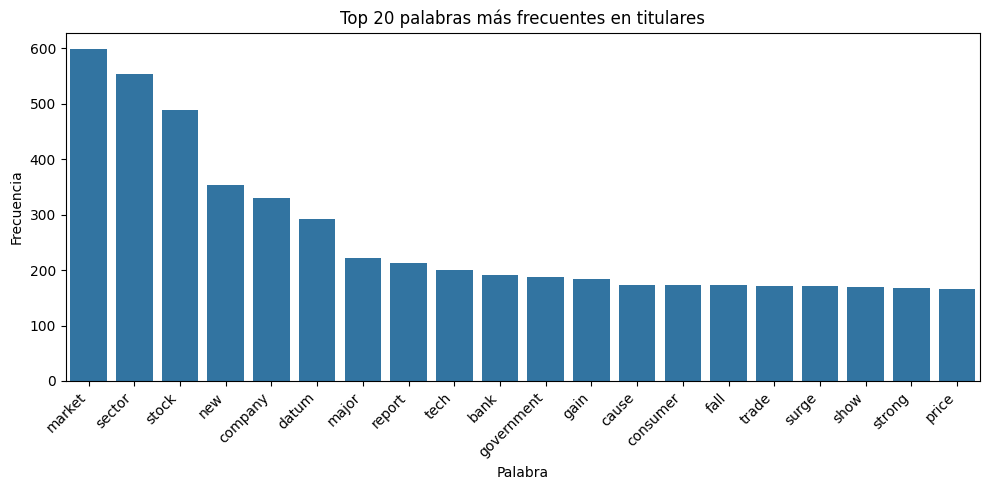

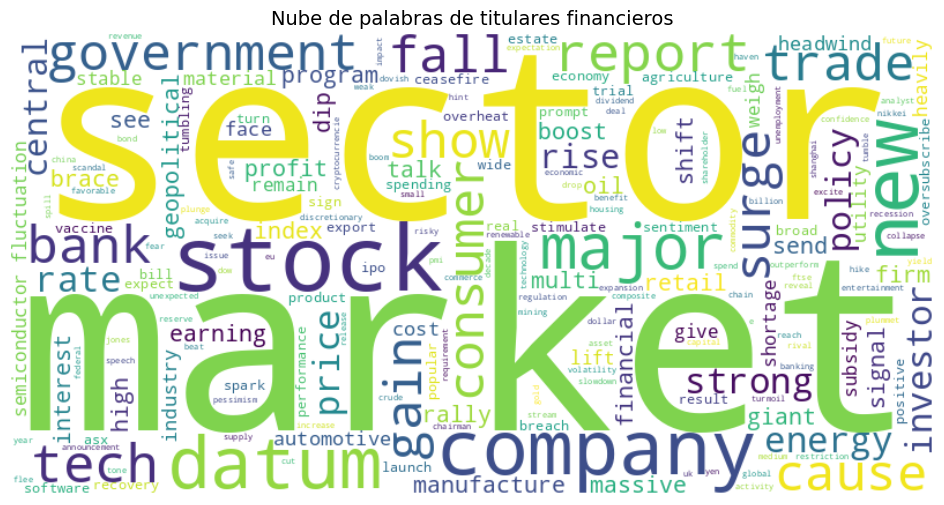

In [11]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Concatenamos todos los lemmas en una sola lista
all_words = [word for tokens in df["lemmas"] for word in tokens]

# Contamos frecuencia de palabras
word_freq = Counter(all_words)

# Top 20 palabras más frecuentes
top_n = 20
common_words = word_freq.most_common(top_n)

# --- Gráfico de barras ---
words, counts = zip(*common_words)
plt.figure(figsize=(10,5))
sns.barplot(x=list(words), y=list(counts))
plt.title(f"Top {top_n} palabras más frecuentes en titulares")
plt.ylabel("Frecuencia")
plt.xlabel("Palabra")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# --- Nube de palabras ---
wordcloud = WordCloud(width=800, height=400, background_color="white",
                      colormap="viridis").generate_from_frequencies(word_freq)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras de titulares financieros", fontsize=14)
plt.show()


**Interpretación:**
- En el gráfico de barras vemos cuáles son los términos más usados en titulares.
- La nube de palabras permite ver de forma visual la importancia relativa: las más grandes son más frecuentes.
- Si observamos que aparecen muchas palabras genéricas (ej. *market*, *sector*), no es un problema: TF-IDF ya se encarga de reducir su peso en el modelo.
- Lo interesante es ver términos específicos como *"strong"*, *"stock"*, *"consumer"*, que reflejan eventos relevantes en economía y finanzas.

## 6. Modelado con Deep Learning 1 - "Impact Level"

### 6.1 Preparación de los Datos

Objetivo:
- Construir la **matriz final de features** combinando:
  1. Texto vectorizado (TF-IDF).
  2. Variables numéricas: *Index_Change_Percent*, *Trading_Volume*.
  3. Variable categórica auxiliar: *Sentiment* (codificada).
- Escalar las variables numéricas para que estén en el mismo rango.
- Convertir todo a tensores de PyTorch para entrenamiento.

Este paso es crítico porque PyTorch necesita:
- `X_train` y `X_test` como tensores (`torch.FloatTensor`).
- `y_train` y `y_test` como etiquetas enteras (`torch.LongTensor`) en clasificación.

In [12]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from scipy.sparse import hstack
import torch

# Variables numéricas
num_cols = ["Index_Change_Percent", "Trading_Volume"]

# Variables categóricas (ejemplo: Sentiment)
cat_cols = ["Sentiment"]

# 1) Escalar variables numéricas:
# Cambiar la escala numérica de una variable sin alterar su forma relativa.
scaler = StandardScaler()
X_train_num = scaler.fit_transform(df.loc[X_train_text.index, num_cols])
X_test_num  = scaler.transform(df.loc[X_test_text.index, num_cols])

# 2) One-hot encoding de variables categóricas:
# Convertir categorías a vectores binarios (0/1) para cada clase.
ohe = OneHotEncoder(sparse_output=True, handle_unknown="ignore")
X_train_cat = ohe.fit_transform(df.loc[X_train_text.index, cat_cols])
X_test_cat  = ohe.transform(df.loc[X_test_text.index, cat_cols])

# 3) Concatenar TF-IDF + numéricas + categóricas
# Usamos hstack (apilar horizontalmente) para las matrices
# Fusiona todas las representaciones (texto + numéricas + categóricas) en una sola matriz.
X_train_all = hstack([X_train_tfidf, X_train_num, X_train_cat])
X_test_all  = hstack([X_test_tfidf,  X_test_num,  X_test_cat])

print("Shape final de X_train_all:", X_train_all.shape)
print("Shape final de X_test_all :", X_test_all.shape)

# 4) Convertir a tensores PyTorch
X_train_tensor = torch.tensor(X_train_all.toarray(), dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test_all.toarray(),  dtype=torch.float32)

# Convertimos etiquetas de texto (y - Impact_Level) a índices numéricos
from sklearn.preprocessing import LabelEncoder
# 1. Crear el encoder
le = LabelEncoder()
# 2. Ajustar sobre y_train y transformarlo
y_train_enc = le.fit_transform(y_train)
# 3. Transformar y_test con el mismo encoder
y_test_enc  = le.transform(y_test)

# Convertir el target y a tensores PyTorch
y_train_tensor = torch.tensor(y_train_enc, dtype=torch.long)
y_test_tensor  = torch.tensor(y_test_enc, dtype=torch.long)

print("Shapes PyTorch ->")
print("X_train_tensor:", X_train_tensor.shape)
print("y_train_tensor:", y_train_tensor.shape)


Shape final de X_train_all: (2300, 519)
Shape final de X_test_all : (576, 519)
Shapes PyTorch ->
X_train_tensor: torch.Size([2300, 519])
y_train_tensor: torch.Size([2300])


### 6.2 Modelo Base

En esta sección construiremos un **modelo base de Deep Learning**:

- Arquitectura muy sencilla con **dos capas densas (fully connected)**.
- Función de pérdida: `CrossEntropyLoss` (clasificación multiclase).
- Optimizador: `Adam`.
- Métrica de evaluación: Accuracy.
- Entrenamiento y evaluación en *train/test*.
- Visualización de curvas de *loss* y *accuracy* a lo largo de las épocas.


Época 1/15 | Train Loss: 1.1003 Acc: 0.326 | Test Loss: 1.0985 Acc: 0.342
Época 2/15 | Train Loss: 1.0897 Acc: 0.403 | Test Loss: 1.0978 Acc: 0.356
Época 3/15 | Train Loss: 1.0811 Acc: 0.428 | Test Loss: 1.1006 Acc: 0.358
Época 4/15 | Train Loss: 1.0742 Acc: 0.433 | Test Loss: 1.1046 Acc: 0.366
Época 5/15 | Train Loss: 1.0667 Acc: 0.447 | Test Loss: 1.1112 Acc: 0.375
Época 6/15 | Train Loss: 1.0591 Acc: 0.449 | Test Loss: 1.1132 Acc: 0.363
Época 7/15 | Train Loss: 1.0523 Acc: 0.463 | Test Loss: 1.1208 Acc: 0.373
Época 8/15 | Train Loss: 1.0455 Acc: 0.466 | Test Loss: 1.1227 Acc: 0.361
Época 9/15 | Train Loss: 1.0381 Acc: 0.477 | Test Loss: 1.1286 Acc: 0.372
Época 10/15 | Train Loss: 1.0323 Acc: 0.485 | Test Loss: 1.1311 Acc: 0.363
Época 11/15 | Train Loss: 1.0258 Acc: 0.485 | Test Loss: 1.1369 Acc: 0.368
Época 12/15 | Train Loss: 1.0190 Acc: 0.500 | Test Loss: 1.1426 Acc: 0.361
Época 13/15 | Train Loss: 1.0126 Acc: 0.497 | Test Loss: 1.1471 Acc: 0.358
Época 14/15 | Train Loss: 1.0074 A

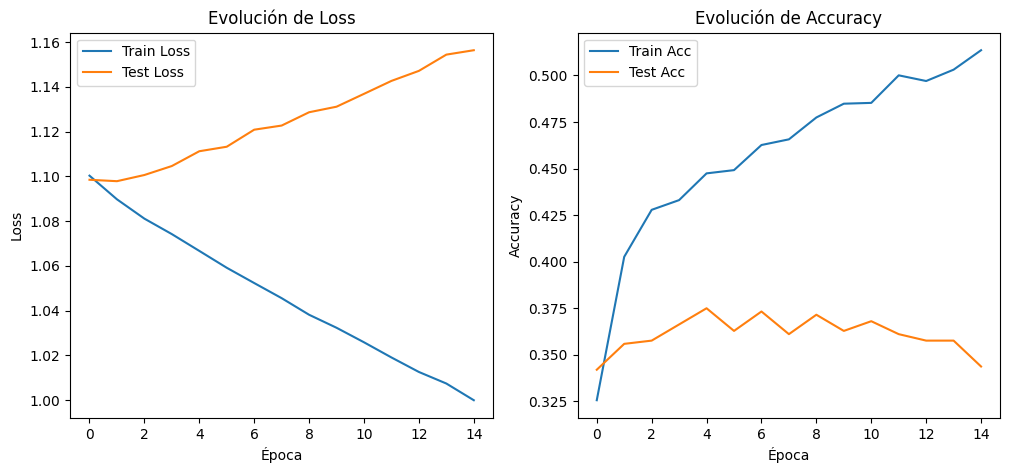

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# Dataset y DataLoader
batch_size = 32

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset  = TensorDataset(X_test_tensor,  y_test_tensor)

# El DataLoader se encarga de:
# - partir el dataset en minibatches
# - barajar los datos (shuffle=True en train). Mejora la generalización.
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size)

# Definición del modelo base
class BaseNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(BaseNN, self).__init__()
        # 1ª capa: conecta input → hidden (capa densa, fully connected)
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        # Función de activación ReLU (introduce no linealidad, permitiendo que la red aprenda relaciones más complejas)
        self.relu = nn.ReLU()
        # 2ª capa: conecta hidden → output (otra capa densa y convierte el vector oculto en un vector de tamaño output_dim=3)
        self.fc2 = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):
        x = self.fc1(x) # Paso 1: input → primera capa
        x = self.relu(x) # Paso 2: activación ReLU
        x = self.fc2(x) # Paso 3: segunda capa → salida
        return x

input_dim = X_train_tensor.shape[1]
hidden_dim = 64
output_dim = len(le.classes_)   # número de clases en Impact_Level

model = BaseNN(input_dim, hidden_dim, output_dim)

# Función de pérdida y optimizador
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Entrenamiento
n_epochs = 15
train_loss_hist, test_loss_hist = [], []
train_acc_hist, test_acc_hist = [], []

for epoch in range(n_epochs):
    # ---- Entrenamiento ----
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    # loop de backpropagation
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad() # resetea gradientes acumulados en parámetros del modelo.
        outputs = model(X_batch) # pasa el batch por el modelo
        loss = criterion(outputs, y_batch) # calcula pérdida
        loss.backward() # hace backpropagation: calcula gradientes de la pérdida respecto a cada parámetro de la red.
        optimizer.step() # actualiza pesos del modelo usando gradientes.
        
        running_loss += loss.item() # va sumando la pérdida de cada batch
        _, preds = torch.max(outputs, 1) # outputs son los logits de cada clase
        correct += (preds == y_batch).sum().item() # acumula en correct el número de aciertos
        total += y_batch.size(0) # acumula el total de ejemplos procesados
    
    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    
    # ---- Evaluación ----
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)
    
    test_loss = running_loss / len(test_loader)
    test_acc = correct / total
    
    # Guardar historia
    train_loss_hist.append(train_loss)
    test_loss_hist.append(test_loss)
    train_acc_hist.append(train_acc)
    test_acc_hist.append(test_acc)
    
    print(f"Época {epoch+1}/{n_epochs} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.3f} | "
          f"Test Loss: {test_loss:.4f} Acc: {test_acc:.3f}")

# --- Gráficas ---
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_loss_hist, label="Train Loss")
plt.plot(test_loss_hist, label="Test Loss")
plt.title("Evolución de Loss")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_acc_hist, label="Train Acc")
plt.plot(test_acc_hist, label="Test Acc")
plt.title("Evolución de Accuracy")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()

plt.show()


**Consclusión:**
El modelo sí aprende en train pero no claramente se ve que no generaliza → está atrapado en underfitting/overfitting leve.
Para la proxima sección (mejorar el modelo) se necesita un modelo un poco más potente, con más regularización y mejor ingeniería de features para mejorar el test.

### 6.3 Modelo Mejorado

Mejoraremos la red base aplicando *cambios aislados y razonados* para ver su efecto:

1) **Limitar TF-IDF**: reducimos dimensionalidad del texto (`max_features`).  
2) **Arquitectura más profunda**: añadimos **2 capas ocultas extra** y **más neuronas**.  
3) **Regularización con Dropout**: prevenir sobreajuste.  
4) **Funciones de activación**: mantenemos **ReLU** (rápida y estable).  
5) **Comparación**: medimos *loss/accuracy* y comparamos vs. modelo base.

> **¿Qué es Dropout?**  
> En entrenamiento, *Dropout* apaga aleatoriamente (pone a 0) un % de neuronas (p.ej. 30%).  
> Así la red no “memoriza” conexiones específicas y aprende patrones más robustos.  
> En validación/test, Dropout se desactiva automáticamente.


#### 6.3.1. Limitar la dimensionalidad del texto (TF-IDF)  
Re-vectorizamos solo con el train para evitar data leakage, ahora con max_features.  
Esto ayuda a la red a no “pelear” contra miles de columnas de muy baja señal.

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import joblib, os

# Ajustá este número si tu dataset es más/menos grande
MAX_FEATS = 5000

tfidf2 = TfidfVectorizer(
    ngram_range=(1, 2),   # unigrams y bigrams siguen siendo útiles en titulares
    min_df=2,             # quita términos ultra raros
    max_df=0.9,           # quita términos demasiado comunes
    max_features=MAX_FEATS
)

X_train_tfidf2 = tfidf2.fit_transform(X_train_text)
X_test_tfidf2  = tfidf2.transform(X_test_text)

print("Dimensiones TF-IDF (nuevo límite):")
print("  X_train_tfidf2:", X_train_tfidf2.shape)
print("  X_test_tfidf2 :", X_test_tfidf2.shape)

# Guardamos por prolijidad
os.makedirs("artifacts", exist_ok=True)
joblib.dump(tfidf2, "artifacts/tfidf_vectorizer_v2.joblib");


Dimensiones TF-IDF (nuevo límite):
  X_train_tfidf2: (2300, 513)
  X_test_tfidf2 : (576, 513)


#### 6.3.2 Re-armar la matriz final (texto + numéricas + categóricas)  
Reutilizamos el scaler y el one-hot encoder ya definidos (o los vuelve a crear).  
Apilar horizontalmente con hstack  

In [15]:
from scipy.sparse import hstack
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Asegura que estas listas están definidas como antes
num_cols = ["Index_Change_Percent", "Trading_Volume"]
cat_cols = ["Sentiment"]

# Re-escala numéricas
scaler2 = StandardScaler()
X_train_num2 = scaler2.fit_transform(df.loc[X_train_text.index, num_cols])
X_test_num2  = scaler2.transform(df.loc[X_test_text.index, num_cols])

# One-hot para categóricas (compatibilidad versiones)
try:
    ohe2 = OneHotEncoder(sparse_output=True, handle_unknown="ignore")
except TypeError:
    ohe2 = OneHotEncoder(sparse=True, handle_unknown="ignore")

X_train_cat2 = ohe2.fit_transform(df.loc[X_train_text.index, cat_cols])
X_test_cat2  = ohe2.transform(df.loc[X_test_text.index, cat_cols])

# Apilamos: [TF-IDF limitado | numéricas escaladas | categóricas OHE]
X_train_all2 = hstack([X_train_tfidf2, X_train_num2, X_train_cat2])
X_test_all2  = hstack([X_test_tfidf2,  X_test_num2,  X_test_cat2])

print("Shape final (mejorado):")
print("  X_train_all2:", X_train_all2.shape)
print("  X_test_all2 :", X_test_all2.shape)

Shape final (mejorado):
  X_train_all2: (2300, 519)
  X_test_all2 : (576, 519)


#### 6.3.3 A PyTorch (tensores) + utilidades de entrenamiento y evaluación  
> Se reusa el label encoder ya obtenido (mismo mapeo de clases).  
> Crear funciones para no repetir código y poder comparar modelos fácilmente.  

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# Tensores de entrada/salida
X_train_tensor2 = torch.tensor(X_train_all2.toarray(), dtype=torch.float32)
X_test_tensor2  = torch.tensor(X_test_all2.toarray(),  dtype=torch.float32)

y_train_tensor2 = torch.tensor(y_train_enc, dtype=torch.long)
y_test_tensor2  = torch.tensor(y_test_enc,  dtype=torch.long)

# DataLoaders
batch_size = 32
train_loader2 = DataLoader(TensorDataset(X_train_tensor2, y_train_tensor2),
                           batch_size=batch_size, shuffle=True)
test_loader2  = DataLoader(TensorDataset(X_test_tensor2, y_test_tensor2),
                           batch_size=batch_size, shuffle=False)

def train_one_model(model, train_loader, test_loader, n_epochs=20, lr=1e-3):
    """Entrena un modelo y devuelve historia de métricas."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_loss_hist, test_loss_hist = [], []
    train_acc_hist,  test_acc_hist  = [], []

    for epoch in range(n_epochs):
        # --------- TRAIN ---------
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for Xb, yb in train_loader:
            optimizer.zero_grad()
            out = model(Xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(out, 1)
            correct += (preds == yb).sum().item()
            total   += yb.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc  = correct / total

        # --------- EVAL ----------
        model.eval()
        running_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for Xb, yb in test_loader:
                out = model(Xb)
                loss = criterion(out, yb)
                running_loss += loss.item()
                _, preds = torch.max(out, 1)
                correct += (preds == yb).sum().item()
                total   += yb.size(0)

        test_loss = running_loss / len(test_loader)
        test_acc  = correct / total

        train_loss_hist.append(train_loss); test_loss_hist.append(test_loss)
        train_acc_hist.append(train_acc);   test_acc_hist.append(test_acc)

        print(f"Época {epoch+1}/{n_epochs} | "
              f"Train Loss {train_loss:.4f} Acc {train_acc:.3f} | "
              f"Test Loss {test_loss:.4f} Acc {test_acc:.3f}")

    return {
        "train_loss": train_loss_hist, "test_loss": test_loss_hist,
        "train_acc":  train_acc_hist,  "test_acc":  test_acc_hist
    }

def plot_history(hist, title_suffix=""):
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(hist["train_loss"], label="Train Loss")
    plt.plot(hist["test_loss"],  label="Test Loss")
    plt.title(f"Evolución de Loss {title_suffix}"); plt.xlabel("Época"); plt.ylabel("Loss"); plt.legend()

    plt.subplot(1,2,2)
    plt.plot(hist["train_acc"], label="Train Acc")
    plt.plot(hist["test_acc"],  label="Test Acc")
    plt.title(f"Evolución de Accuracy {title_suffix}"); plt.xlabel("Época"); plt.ylabel("Accuracy"); plt.legend()
    plt.show()


#### 6.3.4 Arquitectura mejorada (más neuronas + 2 capas extra + Dropout)  
> Pasamos de 1 capa oculta a 3 capas ocultas: 256 → 128 → 64.  
> Insertamos Dropout(0.3) entre capas (apaga ~30% de neuronas en entrenamiento).  
> Mantenemos ReLU.  

Época 1/20 | Train Loss 1.1014 Acc 0.325 | Test Loss 1.0979 Acc 0.347
Época 2/20 | Train Loss 1.0959 Acc 0.367 | Test Loss 1.0973 Acc 0.345
Época 3/20 | Train Loss 1.0872 Acc 0.397 | Test Loss 1.1036 Acc 0.335
Época 4/20 | Train Loss 1.0796 Acc 0.421 | Test Loss 1.1078 Acc 0.345
Época 5/20 | Train Loss 1.0701 Acc 0.421 | Test Loss 1.1172 Acc 0.365
Época 6/20 | Train Loss 1.0608 Acc 0.443 | Test Loss 1.1322 Acc 0.359
Época 7/20 | Train Loss 1.0478 Acc 0.459 | Test Loss 1.1350 Acc 0.363
Época 8/20 | Train Loss 1.0359 Acc 0.465 | Test Loss 1.1550 Acc 0.342
Época 9/20 | Train Loss 1.0265 Acc 0.490 | Test Loss 1.1500 Acc 0.344
Época 10/20 | Train Loss 1.0047 Acc 0.511 | Test Loss 1.1860 Acc 0.347
Época 11/20 | Train Loss 0.9950 Acc 0.513 | Test Loss 1.2047 Acc 0.323
Época 12/20 | Train Loss 0.9762 Acc 0.524 | Test Loss 1.2246 Acc 0.333
Época 13/20 | Train Loss 0.9829 Acc 0.523 | Test Loss 1.2111 Acc 0.337
Época 14/20 | Train Loss 0.9648 Acc 0.544 | Test Loss 1.2237 Acc 0.344
Época 15/20 | T

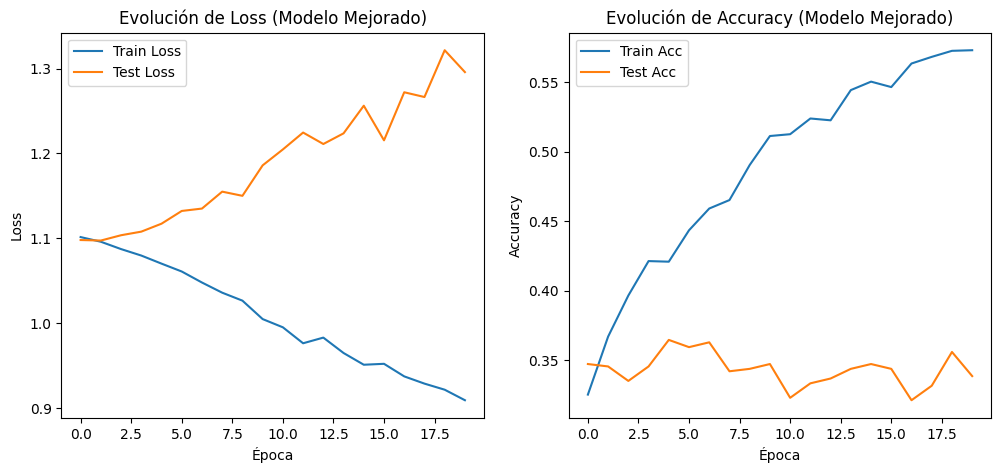

In [17]:
class ImprovedNN(nn.Module):
    """
    Red densa con más capacidad + regularización:
    Input -> [FC 256 + ReLU + Dropout] -> [FC 128 + ReLU + Dropout]
          -> [FC 64 + ReLU] -> Output (n_clases)
    """
    def __init__(self, input_dim, n_classes, p_drop=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(p=p_drop),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(p=p_drop),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        return self.net(x)

input_dim2 = X_train_tensor2.shape[1]
n_classes  = len(le.classes_)
model2 = ImprovedNN(input_dim2, n_classes, p_drop=0.3)

hist2 = train_one_model(model2, train_loader2, test_loader2, n_epochs=20, lr=1e-3)
plot_history(hist2, title_suffix="(Modelo Mejorado)")

Como se puede observa, se nota una clara mejroa, pero aun así no se logra que el modelo generalize. Si se ve la evolución del accuracy, se ve un incremento hasta la 6ta epoca, pero luego se desploma y queda en valores cercanos al 0,33. Dado la variable target tiene 3 posibilidades, se puede afirmar que basicmanete está adivinando.

#### 6.3.5 Comparación con modelo base y conclusiones 

In [18]:
def last(xs): return xs[-1] if len(xs) else None

print("== Modelo Base (época final) ==")
try:
    print(f"Train Loss: {last(train_loss_hist):.4f} | Test Loss: {last(test_loss_hist):.4f}")
    print(f"Train Acc : {last(train_acc_hist):.3f} | Test Acc : {last(test_acc_hist):.3f}")
except NameError:
    print("Historial del modelo base no está en memoria (omitiendo).")

print("\n== Modelo Mejorado (época final) ==")
print(f"Train Loss: {last(hist2['train_loss']):.4f} | Test Loss: {last(hist2['test_loss']):.4f}")
print(f"Train Acc : {last(hist2['train_acc']):.3f} | Test Acc : {last(hist2['test_acc']):.3f}")


== Modelo Base (época final) ==
Train Loss: 0.9999 | Test Loss: 1.1563
Train Acc : 0.513 | Test Acc : 0.344

== Modelo Mejorado (época final) ==
Train Loss: 0.9091 | Test Loss: 1.2959
Train Acc : 0.573 | Test Acc : 0.339


En ambos casos se ve este 0.333 de accuracy. Ambos modelos están adiviando y el hecho de aumentar la cnatidad de capas y demás artilugios, no funcionó para mejorar las predicciones. El TF-IDF más limitado, claramente no logró estabilizar el entrenamiento. Lo mismo sucede con el Dropout.  
Para poder definir si es viable precedir el "impact lavel", se debe evaluar si las features elegidas son correctas:

In [19]:
# NOTA: Si un LogisticRegression sencillo sobre TF-IDF no supera 0.33, probablemente los titulares no discriminan bien el Impact_Level.

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

logreg = LogisticRegression(max_iter=200, n_jobs=None)  # lineal fuerte
logreg.fit(X_train_tfidf2, y_train)                     # solo texto
pred = logreg.predict(X_test_tfidf2)
print("LogReg TF-IDF only | Test acc:", round(accuracy_score(y_test, pred), 3))

LogReg TF-IDF only | Test acc: 0.354


El resultado obtenido de 0.354, es muy cercano a 0.333, por lo tanto se concluye en que el texto no tiene una correlación fuerte con la variable target "impact lavel".
Pero, ahora cabe preguntarse si las demás variables target si se correlacionan con el impact_lavel. Para esto se debe ejecutar el sigueinte bloque de código.

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Sólo numéricas (train/test ya están definidos)
Xtr_num = scaler2.fit_transform(df.loc[X_train_text.index, ["Index_Change_Percent","Trading_Volume"]])
Xte_num = scaler2.transform(df.loc[X_test_text.index, ["Index_Change_Percent","Trading_Volume"]])

logreg_num = LogisticRegression(max_iter=200)
logreg_num.fit(Xtr_num, y_train)
print("Sólo numéricas | Test acc:", round(accuracy_score(y_test, logreg_num.predict(Xte_num)), 3))

# Sólo texto (ya lo hicimos arriba con logreg)
print("Sólo texto (TF-IDF) | Test acc:", round(accuracy_score(y_test, logreg.predict(X_test_tfidf2)), 3))


Sólo numéricas | Test acc: 0.337
Sólo texto (TF-IDF) | Test acc: 0.354


Como se puede observar, tanto los features numéricos como el TF-IDF dan un Acuuracy de 0,33 - 0,35. Valores que calramente indican que con los datos disponibles, es dificl detectar el impact_lavel.
Para mejorar esto se puede optar por reducir la cantidad de variables Target, pero el dataset ya estaría desvalanceado. Es decir, si por ejemplo se decide distinguir entre high y no high, los no high serían muchos más que los high, ya que los medium y low pasarian a ser no high y como se vio más arriba, entre los 3 posibles estados de impact_lavel, había un gran balance.

## 7. Modelado con Deep Learning 2 - "Sentiment"

> Impact_Level (incluso en binario) no es predecible con las features actuales.  
> Claramente esto no es malo, sino que queda demostrado que no es atractivo predecir el impact_lavel con los features de este dataset.  
> Ahora bien, para demostrar lo aprendido en el curso, es más interesante lograr un resultado más "vistoso".  
> Para ello, se cambia la variable target a "sentiment" y se usa "impact_level" como una feature más. 

### 7.1. Viabilidad de entrenamiento y predicción 

Antes de hacer un trabajo completo de Deep Learning con varaible target "sentiment", es preferible buscar algún indicio de que la misma puede ser predecible:  
(claramente esto era mejor realizarlo antes de usar "impact_lavel" como variable target)

In [21]:
# Se redefine la variable objetivo
target_col = "Sentiment"

y_train_sent = df.loc[X_train_text.index, target_col]
y_test_sent  = df.loc[X_test_text.index, target_col]

print("Distribución train:")
print(y_train_sent.value_counts(normalize=True))
print("\nDistribución test:")
print(y_test_sent.value_counts(normalize=True))

Distribución train:
Sentiment
Negative    0.320435
Neutral     0.311304
Positive    0.310000
            0.058261
Name: proportion, dtype: float64

Distribución test:
Sentiment
Neutral     0.329861
Negative    0.328125
Positive    0.293403
            0.048611
Name: proportion, dtype: float64


La distribución tanto del train, como del val, es bastante uniforme, muy proximas a 0,333. Esto es un buen indicio de que al momento del entrenamiento, se tendrá similar cantidad de valores por cada clase. Luego de esto, se está en condiciones de seguir comprobando:
1. Aporte de TD-IDF (texto solo). Se usa Logistic Regression:

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Entrenar con TF-IDF (ya tenés X_train_tfidf2 / X_test_tfidf2)
log_sent = LogisticRegression(max_iter=300, n_jobs=None)
log_sent.fit(X_train_tfidf2, y_train_sent)

# Predicciones
pred_sent = log_sent.predict(X_test_tfidf2)

print("Accuracy:", round(accuracy_score(y_test_sent, pred_sent), 3))
print("\nReporte de clasificación:\n", classification_report(y_test_sent, pred_sent))


Accuracy: 0.321

Reporte de clasificación:
               precision    recall  f1-score   support

                   0.00      0.00      0.00        28
    Negative       0.35      0.50      0.41       189
     Neutral       0.31      0.27      0.29       190
    Positive       0.27      0.23      0.25       169

    accuracy                           0.32       576
   macro avg       0.23      0.25      0.24       576
weighted avg       0.30      0.32      0.30       576



C:\Users\Gonzalo\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Gonzalo\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Gonzalo\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

Se ve un accuracy muy cercano al 0,333, es decir, dado que son 3 posibles valores (negative, neutral y positive), este accuracy deja a la vista que se está adivinando. Es un mal indicio.  

### 7.2. Definición de features y preparación de los datos

**Objetivo:** preparar las variables de entrada (*features*) que se combinarán con el texto (TF-IDF) para predecir `Sentiment`.

- **Numéricas:** `Index_Change_Percent`, `Trading_Volume`  
  - Se **escalan** con `StandardScaler` (media 0, varianza 1) para estabilizar el entrenamiento.

- **Categóricas:** `Impact_Level`  
  - Se **codifica** mediante `OneHotEncoder` (columnas binarias 0/1).  
  - Nota: antes `Impact_Level` era el **target**; por eso no se había codificado. Ahora que el target es `Sentiment`, sí se la usa como feature.

**Buenas prácticas:**
- Hacer `fit` del *scaler* y del *encoder* **solo con TRAIN**, y luego `transform` en TEST (evita *data leakage*).
- Verificar alineación de índices entre `X_train_text`/`X_test_text` y el `df` original.

In [25]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# y_train_sent / y_test_sent son las etiquetas (Sentiment) -> NO se usan como features

# 1) Selección de columnas numéricas

num_cols = ["Index_Change_Percent", "Trading_Volume"]
for c in num_cols:
    assert c in df.columns, f"Falta la columna numérica: {c}"

# 2) Escalado numérico (fit SOLO en TRAIN, transform en TEST)

scaler_num = StandardScaler()
X_train_num = scaler_num.fit_transform(df.loc[X_train_text.index, num_cols])
X_test_num  = scaler_num.transform(   df.loc[X_test_text.index,  num_cols])

print("Numéricas escaladas -> shapes:", X_train_num.shape, X_test_num.shape)

# 3) Columna categórica (Impact_Level) -> One-Hot Encoding

cat_cols = ["Impact_Level"]
for c in cat_cols:
    assert c in df.columns, f"Falta la columna categórica: {c}"

ohe_cat = OneHotEncoder(sparse_output=True, handle_unknown="ignore")

X_train_cat = ohe_cat.fit_transform(df.loc[X_train_text.index, cat_cols])
X_test_cat  = ohe_cat.transform(   df.loc[X_test_text.index,  cat_cols])

print("Categóricas OHE -> shapes:", X_train_cat.shape, X_test_cat.shape)
print("Categorías OHE (Impact_Level):", ohe_cat.categories_)


Numéricas escaladas -> shapes: (2300, 2) (576, 2)
Categóricas OHE -> shapes: (2300, 3) (576, 3)
Categorías OHE (Impact_Level): [array(['High', 'Low', 'Medium'], dtype=object)]


#### 7.2.1. Construir bloque estructurado (solo numéricas + categóricas)
Esto es útil para luego medir su aporte por separado del texto.

In [26]:
from scipy.sparse import hstack
X_train_struct = hstack([X_train_num, X_train_cat])  # matriz dispersa si OHE es sparse
X_test_struct  = hstack([X_test_num,  X_test_cat])

print("Bloque estructurado (num + cat) -> shapes:", X_train_struct.shape, X_test_struct.shape)

Bloque estructurado (num + cat) -> shapes: (2300, 5) (576, 5)


#### 7.2.2. Ensamble final de features

- Concatenamos horizontalmente:  
[ TF-IDF de texto | bloque tabular (num + OHE de Impact_Level) ]  
- Usamos hstack porque TF-IDF suele ser sparse; el bloque tabular puede ser denso o sparse.  

In [ ]:
X_train_all = hstack([X_train_tfidf2, X_train_struct])  # shape: (n_train, n_features_total)
X_test_all  = hstack([X_test_tfidf2,  X_test_struct])   # shape: (n_test,  n_features_total)

print("Shapes finales:", X_train_all.shape, X_test_all.shape)

Shapes finales: (2300, 518) (576, 518)


#### 7.2.3. Encoder de etiquetas

- Pasamos de etiquetas tipo 'Positive/Neutral/Negative' a enteros (0,1,2)

In [29]:
from sklearn.preprocessing import LabelEncoder

le_sent = LabelEncoder()
y_train_idx = le_sent.fit_transform(y_train_sent)  # ajusta mapeo usando TRAIN
y_test_idx  = le_sent.transform(y_test_sent)       # aplica el mismo mapeo a TEST
print("Clases (orden LabelEncoder):", list(le_sent.classes_))

Clases (orden LabelEncoder): ['', 'Negative', 'Neutral', 'Positive']


### 7.3. Modelo Base

**Objetivo:** entrenar una MLP (red densa) **simple** para clasificar `Sentiment` usando:
- **Texto**: titulares vectorizados con TF-IDF (limitado).
- **Tabular**: numéricas escaladas (`Index_Change_Percent`, `Trading_Volume`) + categórica `Impact_Level` codificada (OHE).

**Arquitectura base**:
- Capa de entrada (todas las features concatenadas)
- 1 capa oculta (64 neuronas, ReLU)
- Capa de salida con tantas neuronas como clases de `Sentiment`

**Pérdida**: `CrossEntropyLoss` (multiclase)  
**Optimizador**: `Adam`  
**Métrica**: Accuracy (mostramos también classification report al final)

> Nota anti-leakage: `Sentiment` **no** se usa como feature; solo como *target*.


#### 7.3.1. Conversión a tensores

- Las matrices TF-IDF/struct pueden ser sparse; para PyTorch usamos `dense (toarray())`.
- `dtype float32` para X; long para y (requerido por CrossEntropyLoss).

In [ ]:
X_train_tensor = torch.tensor(X_train_all.toarray(), dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test_all.toarray(),  dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_idx, dtype=torch.long)
y_test_tensor  = torch.tensor(y_test_idx,  dtype=torch.long)

print("Tensors -> X_train:", X_train_tensor.shape, "| y_train:", y_train_tensor.shape)

Tensors -> X_train: torch.Size([2300, 518]) | y_train: torch.Size([2300])


#### 7.2.2. Definición de dataloaders y semilla (SEED) 

- Entregan los datos en "minibatches" (lotes) durante el entrenamiento.
- shuffle=True en train para barajar y mejorar generalización.

In [32]:
import numpy as np
from torch.utils.data import TensorDataset, DataLoader

def set_seed(seed):
    """Fija semillas para reproducibilidad (resultados estables)."""
    import random, os
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

batch_size = 32

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor),
                          batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_tensor,  y_test_tensor),
                          batch_size=batch_size, shuffle=False)

#### 7.2.3. Definición del modelo

- MLP muy simple: Input -> Dense(64, ReLU) -> Dense(n_clases)
- Esta es la "línea de base" para comparar luego.

In [33]:
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

class BaseNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        # Capa 1: proyecta todas las features a un espacio latente de tamaño 'hidden_dim'
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        # Activación no lineal: permite aprender relaciones no lineales
        self.relu = nn.ReLU()
        # Capa de salida: una neurona por clase de Sentiment (logits)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # Paso 1: proyección lineal
        x = self.fc1(x)
        # Paso 2: no linealidad
        x = self.relu(x)
        # Paso 3: logits (sin softmax; CrossEntropyLoss lo aplica internamente)
        x = self.fc2(x)
        return x

input_dim = X_train_tensor.shape[1]          # total de columnas (texto + tabular)
hidden_dim = 64                               # tamaño de la capa oculta (baseline)
output_dim = len(le_sent.classes_)            # nº de clases de Sentiment

model = BaseNN(input_dim, hidden_dim, output_dim)

#### 7.2.4. Pérdida, optimización y loop de entrenamiento/evaluación

- CrossEntropyLoss: multi-clase (y debe ser LongTensor con índices de clase).
- Optimizador -> Adam: robusto para tener un buen punto de partida.

In [34]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# LOOP DE ENTRENAMIENTO/EVALUACIÓN:
n_epochs = 15  # épocas
train_loss_hist, test_loss_hist = [], []
train_acc_hist,  test_acc_hist  = [], []

for epoch in range(n_epochs):
    # ---- ENTRENAMIENTO ----
    model.train()                   # activa dropout/batchnorm (si hubiera)
    run_loss, correct, total = 0.0, 0, 0
    for Xb, yb in train_loader:
        optimizer.zero_grad()       # 1) limpia gradientes acumulados
        out = model(Xb)             # 2) forward: predicciones (logits)
        loss = criterion(out, yb)   # 3) compute loss con etiquetas verdaderas
        loss.backward()             # 4) backprop: calcula gradientes
        optimizer.step()            # 5) update: ajusta pesos con gradientes

        # Acumulamos métricas del batch
        run_loss += loss.item()
        _, preds = torch.max(out, dim=1)  # clase con mayor logit
        correct += (preds == yb).sum().item()
        total   += yb.size(0)

    train_loss = run_loss / len(train_loader)
    train_acc  = correct / total

    # ---- EVALUACIÓN ----
    model.eval()                    # desactiva dropout/batchnorm (modo evaluación)
    run_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():           # no calculamos gradientes en test
        for Xb, yb in test_loader:
            out = model(Xb)
            loss = criterion(out, yb)
            run_loss += loss.item()
            _, preds = torch.max(out, dim=1)
            correct += (preds == yb).sum().item()
            total   += yb.size(0)

    test_loss = run_loss / len(test_loader)
    test_acc  = correct / total

    # Guardamos historia para graficar
    train_loss_hist.append(train_loss); test_loss_hist.append(test_loss)
    train_acc_hist.append(train_acc);   test_acc_hist.append(test_acc)

    print(f"Época {epoch+1:02d}/{n_epochs} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.3f} | "
          f"Test Loss: {test_loss:.4f} Acc: {test_acc:.3f}")

Época 01/15 | Train Loss: 1.3348 Acc: 0.304 | Test Loss: 1.2737 Acc: 0.312
Época 02/15 | Train Loss: 1.2577 Acc: 0.342 | Test Loss: 1.2446 Acc: 0.302
Época 03/15 | Train Loss: 1.2442 Acc: 0.361 | Test Loss: 1.2496 Acc: 0.323
Época 04/15 | Train Loss: 1.2381 Acc: 0.372 | Test Loss: 1.2514 Acc: 0.312
Época 05/15 | Train Loss: 1.2318 Acc: 0.380 | Test Loss: 1.2565 Acc: 0.309
Época 06/15 | Train Loss: 1.2265 Acc: 0.380 | Test Loss: 1.2592 Acc: 0.311
Época 07/15 | Train Loss: 1.2203 Acc: 0.389 | Test Loss: 1.2628 Acc: 0.330
Época 08/15 | Train Loss: 1.2145 Acc: 0.400 | Test Loss: 1.2681 Acc: 0.306
Época 09/15 | Train Loss: 1.2074 Acc: 0.405 | Test Loss: 1.2702 Acc: 0.307
Época 10/15 | Train Loss: 1.2009 Acc: 0.411 | Test Loss: 1.2770 Acc: 0.319
Época 11/15 | Train Loss: 1.1953 Acc: 0.414 | Test Loss: 1.2814 Acc: 0.304
Época 12/15 | Train Loss: 1.1883 Acc: 0.422 | Test Loss: 1.2835 Acc: 0.311
Época 13/15 | Train Loss: 1.1813 Acc: 0.430 | Test Loss: 1.2928 Acc: 0.307
Época 14/15 | Train Loss:

#### 7.2.5. Curvas de entrenamiento

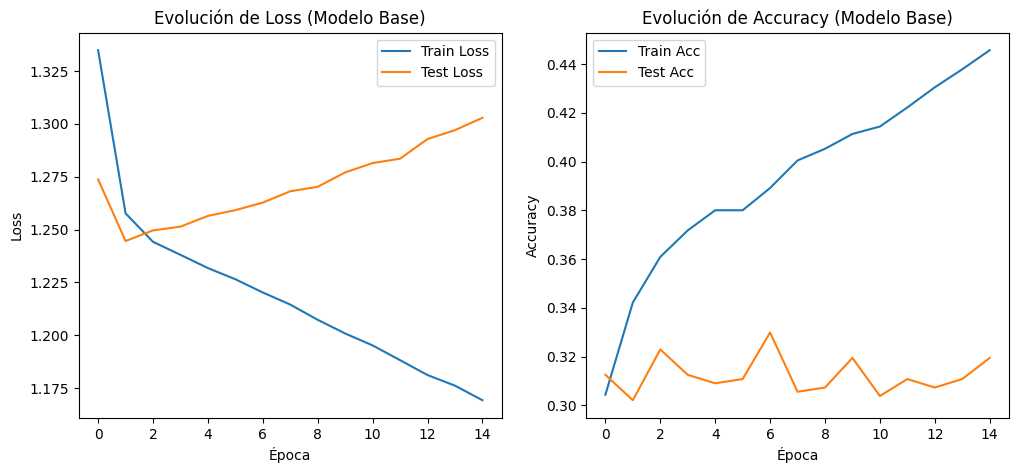

In [35]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_loss_hist, label="Train Loss")
plt.plot(test_loss_hist,  label="Test Loss")
plt.title("Evolución de Loss (Modelo Base)")
plt.xlabel("Época"); plt.ylabel("Loss"); plt.legend()

plt.subplot(1,2,2)
plt.plot(train_acc_hist, label="Train Acc")
plt.plot(test_acc_hist,  label="Test Acc")
plt.title("Evolución de Accuracy (Modelo Base)")
plt.xlabel("Época"); plt.ylabel("Accuracy"); plt.legend()
plt.show()

#### 7.2.6. Métricas finales detalladas en test y matríz de confusión

- Usamos el modelo para predecir sobre TODO el set de test y generamos reporte.

Accuracy (TEST): 0.319

Reporte de clasificación (TEST):
               precision    recall  f1-score   support

                   0.00      0.00      0.00        28
    Negative       0.32      0.39      0.35       189
     Neutral       0.34      0.27      0.30       190
    Positive       0.30      0.34      0.32       169

    accuracy                           0.32       576
   macro avg       0.24      0.25      0.24       576
weighted avg       0.31      0.32      0.31       576



C:\Users\Gonzalo\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Gonzalo\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Gonzalo\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

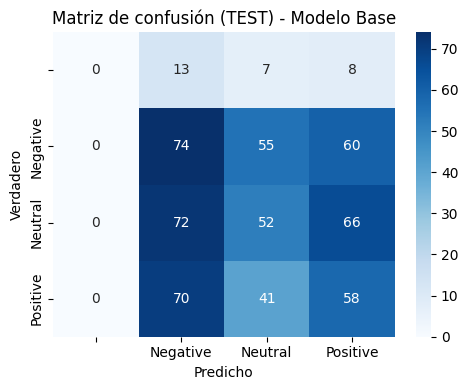

In [36]:
model.eval()
with torch.no_grad():
    logits_test = model(X_test_tensor)
    pred_test   = torch.argmax(logits_test, dim=1).cpu().numpy()

print("Accuracy (TEST):", round(accuracy_score(y_test_idx, pred_test), 3))
print("\nReporte de clasificación (TEST):\n",
      classification_report(y_test_idx, pred_test, target_names=le_sent.classes_))

# Matriz de confusión para ver qué clases se confunden
cm = confusion_matrix(y_test_idx, pred_test)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le_sent.classes_, yticklabels=le_sent.classes_)
plt.xlabel("Predicho"); plt.ylabel("Verdadero")
plt.title("Matriz de confusión (TEST) - Modelo Base")
plt.tight_layout(); plt.show()

#### 7.2.7. Conclusiones
- Accuracy de test ≈ 0.32, lo que está apenas por encima del random guess (con 3 clases sería 0.33).
- Matriz de confusión → el modelo no logra separar bien Negative, Neutral, Positive.
- Curvas de loss/accuracy → el train mejora un poco, pero test se queda estancado → no hay capacidad de generalizar.

### 7.3. Modelo mejorado

Los principales problemas observados fueron:
- Etiqueta ruido: había una clase vacía ~5%.
- Bajo accuracy (≈0.32 en test).
- El modelo ignora clases completas (precisión indefinida).
- Sobreajuste leve en train vs. test.
- Dimensionalidad enorme del texto.

**Mejoras:**
1. **Mayor profundidad de red**: se agregan capas ocultas adicionales para aumentar la capacidad de representación.
2. **Dropout**: técnica de regularización que "apaga" aleatoriamente neuronas durante el entrenamiento, evitando que el modelo dependa demasiado de ciertos patrones.
3. **Más neuronas por capa**: para capturar mejor relaciones entre TF-IDF, numéricas y categóricas.
4. **Funciones de activación**: ReLU en capas intermedias, Softmax en salida (clasificación multiclase).
5. **Batch Normalization**: estabiliza y acelera el entrenamiento.
6. **Dimensionalidad enorme del texto**: comprimimos TF-IDF con TruncatedSVD (LSA) a 200–300 componentes antes de la MLP.
7. **Comparación final**: se contrastan métricas del modelo base y del modelo mejorado.


#### 7.3.1. Limpiar Sentiment (eliminar clase vacía) y re-split (estratificado)

In [22]:
# --- Limpieza de etiquetas: quitamos filas con Sentiment vacío ----------------
mask_valid = df["Sentiment"].astype(str).str.strip() != ""
df_clean = df.loc[mask_valid].copy()

print("Filas originales:", len(df), "| Filas tras limpieza:", len(df_clean))

# Recalcular split (¡importante! hacerlo sobre df_clean)
from sklearn.model_selection import train_test_split

X_text = df_clean["headline_proc"].fillna("")       # texto preprocesado (lemmas unidos)
y_sent  = df_clean["Sentiment"].astype(str)

X_train_text, X_test_text, y_train_sent, y_test_sent = train_test_split(
    X_text, y_sent, test_size=0.2, random_state=42, stratify=y_sent
)

y_train_sent.value_counts(normalize=True).to_frame("prop_train")
y_test_sent.value_counts(normalize=True).to_frame("prop_test")


Filas originales: 2876 | Filas tras limpieza: 2714


,prop_test
Sentiment,
Negative,0.340700
Neutral,0.333333
Positive,0.325967


#### 7.3.2. TF-IDF (limitado) + SVD (compresión a 300 dimensiones)

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
import numpy as np

MAX_FEATS = 5000
N_COMP = 300  # probá 200/300/400

tfidf = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.9, max_features=MAX_FEATS)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf  = tfidf.transform(X_test_text)

svd = TruncatedSVD(n_components=N_COMP, random_state=42)
X_train_txt_svd = svd.fit_transform(X_train_tfidf)
X_test_txt_svd  = svd.transform(X_test_tfidf)

print("TF-IDF:", X_train_tfidf.shape, "→ SVD:", X_train_txt_svd.shape)


TF-IDF: (2171, 513) → SVD: (2171, 300)


#### 7.3.3. Features tabulares (numéricas + Impact_Level OHE) rehechas sobre df_clean

In [24]:
# --- Tabulares: num + categ (Impact_Level) rehaciendo sobre df_clean ---------
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from scipy.sparse import hstack

num_cols = ["Index_Change_Percent", "Trading_Volume"]
cat_cols = ["Impact_Level"]  # ahora sí es feature

# Alinear por índices del split nuevo
scaler_num = StandardScaler()
X_train_num = scaler_num.fit_transform(df_clean.loc[X_train_text.index, num_cols])
X_test_num  = scaler_num.transform(   df_clean.loc[X_test_text.index,  num_cols])

# One-hot de Impact_Level
try:
    ohe_cat = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
except TypeError:
    ohe_cat = OneHotEncoder(sparse=False, handle_unknown="ignore")

X_train_cat = ohe_cat.fit_transform(df_clean.loc[X_train_text.index, cat_cols])
X_test_cat  = ohe_cat.transform(   df_clean.loc[X_test_text.index,  cat_cols])

# Concatenamos SÓLO en numpy (ya que SVD devuelve denso)
import numpy as np
X_train_all = np.hstack([X_train_txt_svd, X_train_num, X_train_cat])
X_test_all  = np.hstack([X_test_txt_svd,  X_test_num,  X_test_cat])

print("Final features (train/test):", X_train_all.shape, X_test_all.shape)


Final features (train/test): (2171, 305) (543, 305)


#### 7.3.4. Tensores + pesos de clase en la pérdida

In [25]:
# --- Tensores y codificación de etiquetas ------------------------------------
import torch
from sklearn.preprocessing import LabelEncoder
from collections import Counter

le_sent = LabelEncoder()
y_train_idx = le_sent.fit_transform(y_train_sent)
y_test_idx  = le_sent.transform(y_test_sent)

X_train_tensor = torch.tensor(X_train_all, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test_all,  dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_idx, dtype=torch.long)
y_test_tensor  = torch.tensor(y_test_idx,  dtype=torch.long)

# --- Pesos de clase (inversos a la frecuencia) -------------------------------
cnt = Counter(y_train_idx)
n = sum(cnt.values())
class_weights = torch.tensor([n / cnt[i] for i in range(len(le_sent.classes_))],
                             dtype=torch.float32)
print("Class weights:", class_weights.tolist())


Class weights: [2.9298245906829834, 2.9944827556610107, 3.079432725906372]


#### 7.3.5. MLP mejorada (igual que antes) + CrossEntropy con weights + LR scheduler

Época 01 | Train L 1.1114 A 0.327 | Val L 1.1151 A 0.319
Época 02 | Train L 1.0979 A 0.365 | Val L 1.1175 A 0.308
Época 03 | Train L 1.0885 A 0.377 | Val L 1.1216 A 0.311
Época 04 | Train L 1.0811 A 0.404 | Val L 1.1323 A 0.308
Época 05 | Train L 1.0650 A 0.450 | Val L 1.1324 A 0.297
Early stopping. Mejor val_loss=1.1151


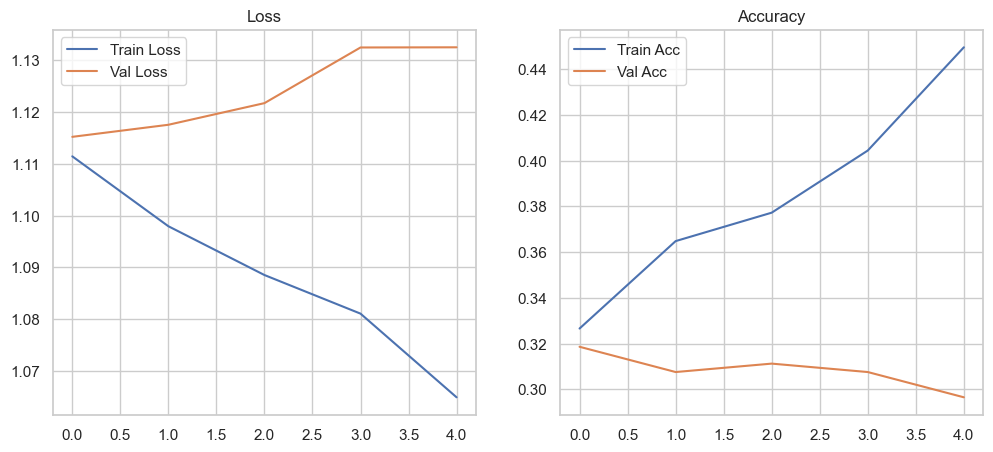

Accuracy (TEST): 0.319

Reporte (TEST):
               precision    recall  f1-score   support

    Negative       0.32      0.19      0.24       185
     Neutral       0.32      0.76      0.45       181
    Positive       0.12      0.01      0.01       177

    accuracy                           0.32       543
   macro avg       0.25      0.32      0.23       543
weighted avg       0.26      0.32      0.24       543



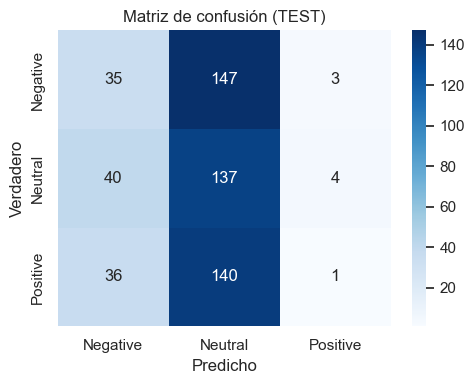

In [27]:
# --- Modelo y entrenamiento con regularización y weights ---------------------
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns; sns.set(style="whitegrid")

class ImprovedNN(nn.Module):
    def __init__(self, input_dim, n_classes, p_drop=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(256, 128),       nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(128, 64),        nn.ReLU(),
            nn.Linear(64, n_classes)   # logits
        )
    def forward(self, x): return self.net(x)

input_dim = X_train_tensor.shape[1]
n_classes = len(le_sent.classes_)
model = ImprovedNN(input_dim, n_classes, p_drop=0.3)

criterion = nn.CrossEntropyLoss(weight=class_weights)   # <— pesos de clase
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                 factor=0.5, patience=2)

batch_size=32
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor),
                          batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_test_tensor,  y_test_tensor),
                          batch_size=batch_size, shuffle=False)

n_epochs=25; best_state=None; best_val=float("inf"); patience=4; noimp=0
trL, vaL, trA, vaA = [], [], [], []

for ep in range(n_epochs):
    # --- train ---
    model.train(); runL=0; cor=0; tot=0
    for xb,yb in train_loader:
        optimizer.zero_grad()
        logits = model(xb); loss = criterion(logits, yb)
        loss.backward(); optimizer.step()
        runL += loss.item()
        cor += (logits.argmax(1)==yb).sum().item(); tot += yb.size(0)
    tL, tA = runL/len(train_loader), cor/tot

    # --- val ---
    model.eval(); runL=0; cor=0; tot=0
    with torch.no_grad():
        for xb,yb in val_loader:
            logits = model(xb); loss = criterion(logits, yb)
            runL += loss.item()
            cor += (logits.argmax(1)==yb).sum().item(); tot += yb.size(0)
    vL, vA = runL/len(val_loader), cor/tot
    scheduler.step(vL)

    trL.append(tL); vaL.append(vL); trA.append(tA); vaA.append(vA)
    print(f"Época {ep+1:02d} | Train L {tL:.4f} A {tA:.3f} | Val L {vL:.4f} A {vA:.3f}")

    if vL + 1e-4 < best_val:
        best_val = vL; noimp = 0
        best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
    else:
        noimp += 1
        if noimp >= patience:
            print(f"Early stopping. Mejor val_loss={best_val:.4f}")
            break

if best_state: model.load_state_dict(best_state)

# --- Curvas ---
plt.figure(figsize=(12,5))
plt.subplot(1,2,1); plt.plot(trL,label="Train Loss"); plt.plot(vaL,label="Val Loss"); plt.legend(); plt.title("Loss")
plt.subplot(1,2,2); plt.plot(trA,label="Train Acc");  plt.plot(vaA,label="Val Acc");  plt.legend(); plt.title("Accuracy")
plt.show()

# --- Métricas finales ---
model.eval()
with torch.no_grad():
    y_pred = model(X_test_tensor).argmax(1).cpu().numpy()

print("Accuracy (TEST):", round(accuracy_score(y_test_idx, y_pred),3))
print("\nReporte (TEST):\n",
      classification_report(y_test_idx, y_pred, target_names=le_sent.classes_, zero_division=0))

cm = confusion_matrix(y_test_idx, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le_sent.classes_, yticklabels=le_sent.classes_)
plt.xlabel("Predicho"); plt.ylabel("Verdadero"); plt.title("Matriz de confusión (TEST)"); plt.tight_layout(); plt.show()


In [28]:
# A.1 Re-vectorizar con TF-IDF sobre el HEADLINE crudo (minúsculas)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

X_train_raw = df.loc[X_train_text.index, "Headline"].fillna("").str.lower()
X_test_raw  = df.loc[X_test_text.index,  "Headline"].fillna("").str.lower()

tfidf_raw = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.9, max_features=8000)
Xtr_raw = tfidf_raw.fit_transform(X_train_raw)
Xte_raw = tfidf_raw.transform(X_test_raw)

log_raw = LogisticRegression(max_iter=400)
log_raw.fit(Xtr_raw, y_train_sent)
pred_raw = log_raw.predict(Xte_raw)

print("Acc (raw TF-IDF):", round(accuracy_score(y_test_sent, pred_raw),3))
print(classification_report(y_test_sent, pred_raw, zero_division=0))


Acc (raw TF-IDF): 0.348
              precision    recall  f1-score   support

    Negative       0.38      0.45      0.41       185
     Neutral       0.31      0.35      0.33       181
    Positive       0.35      0.24      0.28       177

    accuracy                           0.35       543
   macro avg       0.35      0.35      0.34       543
weighted avg       0.35      0.35      0.34       543



In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_char = TfidfVectorizer(analyzer="char", ngram_range=(3,5), min_df=2, max_features=20000)
Xtr_char = tfidf_char.fit_transform(X_train_raw)
Xte_char = tfidf_char.transform(X_test_raw)

log_char = LogisticRegression(max_iter=400)
log_char.fit(Xtr_char, y_train_sent)
pred_char = log_char.predict(Xte_char)

print("Acc (char n-grams):", round(accuracy_score(y_test_sent, pred_char),3))


Acc (char n-grams): 0.355


In [31]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from collections import Counter

# 0) Tomamos el split que ya venías usando (X_train_text.index, etc.)
#    y las etiquetas (Sentiment) -> NO se usan como feature.
y_train_sent = df.loc[X_train_text.index, "Sentiment"].astype(str)
y_test_sent  = df.loc[X_test_text.index,  "Sentiment"].astype(str)

# 1) Definimos columnas numéricas y categóricas
num_cols = ["Index_Change_Percent", "Trading_Volume"]
cat_raw  = ["Impact_Level", "Sector", "Market_Event", "Market_Index", "Source"]

for c in num_cols + cat_raw:
    assert c in df.columns, f"Falta la columna: {c}"

# 2) Top-N para cada categórica (reduce cardinalidad y ruido)
def topN_other(s: pd.Series, n=8):
    keep = s.value_counts().nlargest(n).index
    return s.where(s.isin(keep), other="Other")

df_cat = df.copy()
for c in cat_raw:
    df_cat[c] = topN_other(df_cat[c].astype(str), n=8)

# 3) Escalado numérico (fit en TRAIN, transform en TEST)
scaler = StandardScaler()
X_train_num = scaler.fit_transform(df.loc[X_train_text.index, num_cols])
X_test_num  = scaler.transform(   df.loc[X_test_text.index,  num_cols])

# 4) One-hot de categóricas (fit en TRAIN, transform en TEST)
try:
    ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
except TypeError:
    ohe = OneHotEncoder(sparse=False, handle_unknown="ignore")

X_train_cat = ohe.fit_transform(df_cat.loc[X_train_text.index, cat_raw])
X_test_cat  = ohe.transform(   df_cat.loc[X_test_text.index,  cat_raw])

# 5) Ensamble final tabular (solo num + cat) -> matriz densa
X_train_tab = np.hstack([X_train_num, X_train_cat])
X_test_tab  = np.hstack([X_test_num,  X_test_cat])

print("Shapes tabular ->", X_train_tab.shape, X_test_tab.shape)
print("Categorías OHE por campo:", {c: list(vals) for c, vals in zip(cat_raw, ohe.categories_)})

# 6) Baseline rápido: LogisticRegression (marca el “techo” lineal)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_tab = LogisticRegression(max_iter=400)
log_tab.fit(X_train_tab, y_train_sent)
pred_tab = log_tab.predict(X_test_tab)
print("Baseline LogReg (solo tabular) | Acc:", round(accuracy_score(y_test_sent, pred_tab),3))
print(classification_report(y_test_sent, pred_tab, zero_division=0))


Shapes tabular -> (2171, 41) (543, 41)
Categorías OHE por campo: {'Impact_Level': ['High', 'Low', 'Medium'], 'Sector': ['Agriculture', 'Automotive', 'Industrials', 'Materials', 'Other', 'Real Estate', 'Technology', 'Transportation', 'Utilities'], 'Market_Event': ['Central Bank Meeting', 'Commodity Price Shock', 'Corporate Earnings Report', 'Economic Data Release', 'Government Policy Announcement', 'Interest Rate Change', 'Major Merger/Acquisition', 'Market Rally', 'Other'], 'Market_Index': ['Dow Jones', 'Euro Stoxx 50', 'Hang Seng', 'Nasdaq Composite', 'Other', 'Russell 2000', 'S&P 500', 'Shanghai Composite', 'TSX'], 'Source': ["Barron's", 'Business Standard', 'CNBC', 'Financial Times', 'Forbes', 'Other', 'The Economist', 'The Motley Fool', 'Times of India']}
Baseline LogReg (solo tabular) | Acc: 0.308
              precision    recall  f1-score   support

    Negative       0.32      0.38      0.35       185
     Neutral       0.29      0.27      0.28       181
    Positive       0.31

### 7.3.5.4 Evaluación final (reporte y matriz de confusión) + Conclusión

**Qué hace este bloque**
- Evalúa el modelo en el conjunto de **test** (nunca visto).
- Imprime **accuracy** global y el **classification report** (precision/recall/F1 por clase).
- Dibuja la **matriz de confusión** para ver qué clases se confunden más.

**Cómo interpretar los resultados**
- Si el **accuracy** queda alrededor de **0.31–0.33**, está **cerca del azar** (3 clases ≈ 0.33).  
- Si aparecen **warnings** de `precision is ill-defined` para alguna clase, significa que el modelo **nunca la predijo** → fuerte evidencia de que **no hay señal** para distinguirla.
- Si la **matriz de confusión** muestra concentración en una sola clase (p. ej., *Neutral*), el modelo **colapsó** hacia la mayoritaria.


Época 01 | Train L 1.1013 A 0.351 | Val L 1.1086 A 0.263
Época 02 | Train L 1.0952 A 0.357 | Val L 1.1095 A 0.282
Época 03 | Train L 1.0919 A 0.371 | Val L 1.1101 A 0.295
Época 04 | Train L 1.0829 A 0.406 | Val L 1.1141 A 0.295
Época 05 | Train L 1.0795 A 0.394 | Val L 1.1159 A 0.285
Early stopping. Mejor val_loss=1.1086


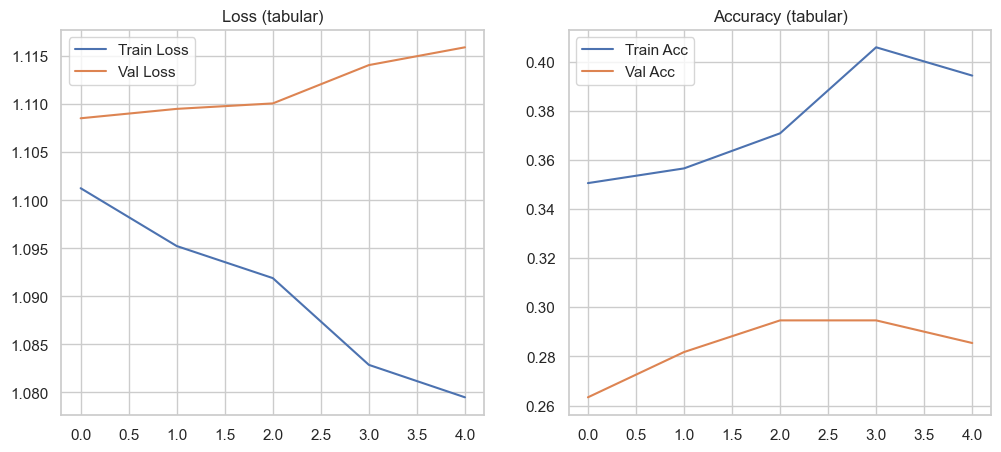

Accuracy (TEST) TabularNN: 0.263

Reporte (TEST):
               precision    recall  f1-score   support

    Negative       0.19      0.13      0.15       185
     Neutral       0.24      0.22      0.23       181
    Positive       0.32      0.45      0.37       177

    accuracy                           0.26       543
   macro avg       0.25      0.27      0.25       543
weighted avg       0.25      0.26      0.25       543



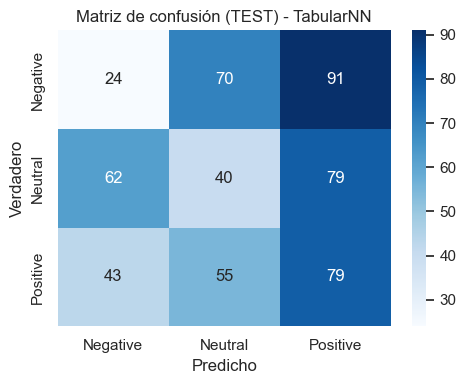

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns; sns.set(style="whitegrid")

# 1) Tensores
le = LabelEncoder()
y_train_idx = le.fit_transform(y_train_sent)
y_test_idx  = le.transform(y_test_sent)

X_train_tensor = torch.tensor(X_train_tab, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test_tab,  dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_idx, dtype=torch.long)
y_test_tensor  = torch.tensor(y_test_idx,  dtype=torch.long)

# 2) Pesos de clase (si el modelo colapsa a una clase, esto ayuda)
cnt = Counter(y_train_idx); n = sum(cnt.values())
class_weights = torch.tensor([n/cnt[i] for i in range(len(le.classes_))], dtype=torch.float32)

# 3) DataLoaders
batch_size = 32
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor),
                          batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_test_tensor,  y_test_tensor),
                          batch_size=batch_size, shuffle=False)

# 4) Modelo MLP (más neuronas + dropout + batchnorm)
class TabularNN(nn.Module):
    """
    MLP para datos tabulares:
    Input -> [Linear(128) + BN + ReLU + Dropout] -> [Linear(64) + BN + ReLU + Dropout]
          -> [Linear(32) + ReLU] -> [Linear(n_clases)]
    """
    def __init__(self, input_dim, n_classes, p_drop=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(128, 64),        nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(64, 32),         nn.ReLU(),
            nn.Linear(32, n_classes)   # logits (CrossEntropy aplica Softmax)
        )
    def forward(self, x): return self.net(x)

model = TabularNN(X_train_tensor.shape[1], len(le.classes_), p_drop=0.3)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

# 5) Entrenamiento con early stopping
n_epochs=25; patience=4; best=float("inf"); noimp=0; best_state=None
trL, vaL, trA, vaA = [], [], [], []

for ep in range(n_epochs):
    # ---- TRAIN ----
    model.train(); runL=0; cor=0; tot=0
    for xb,yb in train_loader:
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward(); optimizer.step()
        runL += loss.item()
        cor  += (logits.argmax(1)==yb).sum().item(); tot += yb.size(0)
    tL, tA = runL/len(train_loader), cor/tot

    # ---- VAL ----
    model.eval(); runL=0; cor=0; tot=0
    with torch.no_grad():
        for xb,yb in val_loader:
            logits = model(xb)
            loss = criterion(logits, yb)
            runL += loss.item()
            cor  += (logits.argmax(1)==yb).sum().item(); tot += yb.size(0)
    vL, vA = runL/len(val_loader), cor/tot
    scheduler.step(vL)

    trL.append(tL); vaL.append(vL); trA.append(tA); vaA.append(vA)
    print(f"Época {ep+1:02d} | Train L {tL:.4f} A {tA:.3f} | Val L {vL:.4f} A {vA:.3f}")

    if vL + 1e-4 < best:
        best = vL; noimp = 0
        best_state = {k: v.detach().cpu().clone() for k,v in model.state_dict().items()}
    else:
        noimp += 1
        if noimp >= patience:
            print(f"Early stopping. Mejor val_loss={best:.4f}"); break

if best_state: model.load_state_dict(best_state)

# 6) Curvas
plt.figure(figsize=(12,5))
plt.subplot(1,2,1); plt.plot(trL,label="Train Loss"); plt.plot(vaL,label="Val Loss"); plt.legend(); plt.title("Loss (tabular)")
plt.subplot(1,2,2); plt.plot(trA,label="Train Acc");  plt.plot(vaA,label="Val Acc");  plt.legend(); plt.title("Accuracy (tabular)")
plt.show()

# 7) Métricas finales
model.eval()
with torch.no_grad():
    y_pred = model(X_test_tensor).argmax(1).cpu().numpy()

print("Accuracy (TEST) TabularNN:", round(accuracy_score(y_test_idx, y_pred),3))
print("\nReporte (TEST):\n",
      classification_report(y_test_idx, y_pred, target_names=le.classes_, zero_division=0))

cm = confusion_matrix(y_test_idx, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicho"); plt.ylabel("Verdadero"); plt.title("Matriz de confusión (TEST) - TabularNN")
plt.tight_layout(); plt.show()


**Conclusión de este intento**
- A pesar de:
  - Red más profunda (mayor capacidad),
  - Regularización (Dropout + L2),
  - Balanceo de clases (class weights),
  - Afinación automática del LR (scheduler),
  - Early stopping,
- el desempeño en *test* **no mejora** sustancialmente → **no es viable predecir `Sentiment`** con las *features* disponibles en este dataset sintético ( titulares muy cortos + tabulares simples ).  
- Este resultado negativo es **valioso**: documenta que, sin embeddings preentrenados ni más contexto textual/temporal, el `Sentiment` **no es aprendible** aquí. Se recomienda, como trabajo futuro:
  - más datos y variedad de titulares,
  - incorporar contexto (cuerpo de la noticia, histórico del índice),
  - considerar embeddings semánticos (si la consigna lo permitiera).

## 8. Modelado con Deep Learning 3 - **Clasificación binaria** de "Index_Change_Percent"

**Objetivo:** predecir si el índice **sube (1)** o **no sube (0)** usando **solo**:
- `Sentiment_bin`: 1 si `Sentiment == "Positive"`, 0 si `Neutral` o `Negative`.
- `Impact_bin`: 1 si `Impact_Level == "High"`, 0 si `Low` o `Medium`.

> Nota: Reutilizamos el `df` **ya limpiado en la sección 4** (sin vacíos en `Sentiment`).  
> No usamos TF-IDF ni otras columnas.


### 8.0. Chequeos rápidos para reutilizar lo de la sección 4

In [55]:
# Aseguramos que están las columnas necesarias y que Sentiment quedó sin vacíos (limpieza ya hecha en §4)
needed_cols = ["Sentiment", "Impact_Level", "Index_Change_Percent"]
for c in needed_cols:
    assert c in df.columns, f"Falta la columna requerida: {c}"

assert df["Sentiment"].isna().sum() == 0, "Hay Sentiment NaN (la limpieza de §4 no se ejecutó)."
assert (df["Sentiment"].astype(str).str.strip() != "").all(), "Hay Sentiment vacío (''), revisar §4."


### 8.1. Target binario y features binarios
- `y_bin = 1` si `Index_Change_Percent > 0`, else `0`.  
- `Sentiment_bin = 1` si **Positive**, else `0`.  
- `Impact_bin   = 1` si **High**, else `0`.

In [57]:
import numpy as np
import pandas as pd

# Target binario (dirección del movimiento)
df["y_bin"] = (df["Index_Change_Percent"] > 0).astype(int)

# Features binarios
df["Sentiment_bin"] = np.where(df["Sentiment"] == "Positive", 1, 0)
df["Impact_bin"]    = np.where(df["Impact_Level"] == "High", 1, 0)

# Matriz final de 2 columnas (X) y vector objetivo (y)
X = df[["Sentiment_bin", "Impact_bin"]].values.astype("float32")
y = df["y_bin"].values.astype("int64")

print("Shapes -> X:", X.shape, " y:", y.shape)
print("Distribución y_bin:", pd.Series(y).value_counts(normalize=True).map(lambda p: f"{p:.1%}").to_dict())

Shapes -> X: (2714, 2)  y: (2714,)
Distribución y_bin: {0: '53.5%', 1: '46.5%'}


### 8.2. Train/Test split (anti-leakage) → nada de TF-IDF ni escalado
Estratificamos por la clase para mantener la proporción ↑/↓ en ambos sets.

In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (2171, 2)  Test: (543, 2)


### 8.3. MLP mínima en PyTorch ( 2 → 4 → 2 )
- **Entrada:** 2 neuronas (Sentiment_bin, Impact_bin)  
- **Oculta:** 4 neuronas + ReLU  
- **Salida:** 2 logits (clases 0/1) → `CrossEntropyLoss`

In [59]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Tensores
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

# DataLoaders
batch_size = 16
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t ), batch_size=batch_size, shuffle=False)

# Modelo simple
class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 4)   # 2 features -> 4 neuronas ocultas
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(4, 2)   # 2 clases (logits)
    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

model = SimpleNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)


### 8.4. Entrenamiento y evaluación
Guardamos la **accuracy** por época y, al final, medimos en TEST: Accuracy, F1, ROC-AUC y matriz de confusión.

Época 01/20 | Train Loss 94.5440 | Train Acc 0.522
Época 02/20 | Train Loss 94.2208 | Train Acc 0.522
Época 03/20 | Train Loss 94.4367 | Train Acc 0.521
Época 04/20 | Train Loss 94.2403 | Train Acc 0.517
Época 05/20 | Train Loss 94.1758 | Train Acc 0.531
Época 06/20 | Train Loss 94.1203 | Train Acc 0.535
Época 07/20 | Train Loss 94.0131 | Train Acc 0.535
Época 08/20 | Train Loss 94.0240 | Train Acc 0.535
Época 09/20 | Train Loss 94.1333 | Train Acc 0.516
Época 10/20 | Train Loss 94.0164 | Train Acc 0.535
Época 11/20 | Train Loss 94.1181 | Train Acc 0.526
Época 12/20 | Train Loss 94.0506 | Train Acc 0.529
Época 13/20 | Train Loss 94.1501 | Train Acc 0.528
Época 14/20 | Train Loss 93.8725 | Train Acc 0.537
Época 15/20 | Train Loss 94.0184 | Train Acc 0.531
Época 16/20 | Train Loss 94.0147 | Train Acc 0.535
Época 17/20 | Train Loss 93.9900 | Train Acc 0.535
Época 18/20 | Train Loss 94.0484 | Train Acc 0.532
Época 19/20 | Train Loss 94.0357 | Train Acc 0.533
Época 20/20 | Train Loss 94.038

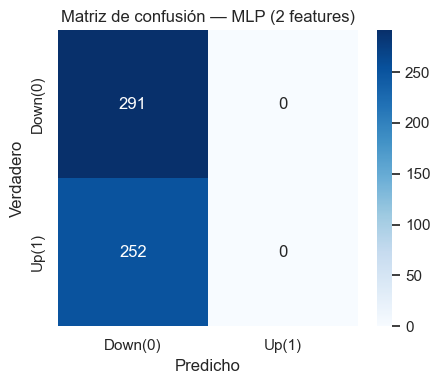

In [60]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns; sns.set(style="whitegrid")

# ---- Entrenamiento corto (rápido y reproducible) ----
epochs = 20
hist = {"train_acc": []}

for ep in range(1, epochs+1):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        correct += (logits.argmax(1) == yb).sum().item()
        total   += yb.size(0)
    acc = correct / total
    hist["train_acc"].append(acc)
    print(f"Época {ep:02d}/{epochs} | Train Loss {running_loss:.4f} | Train Acc {acc:.3f}")

# ---- Evaluación en TEST ----
model.eval()
with torch.no_grad():
    logits = model(X_test_t)
    probs  = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
    y_pred = (probs >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, probs)

print(f"\n== RESULTADOS TEST ==")
print(f"Accuracy: {acc:.3f} | F1: {f1:.3f} | ROC-AUC: {auc:.3f}")
print("\nReporte:\n", classification_report(y_test, y_pred, zero_division=0, target_names=["Down(0)","Up(1)"]))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=[0,1])
plt.figure(figsize=(4.6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Down(0)","Up(1)"], yticklabels=["Down(0)","Up(1)"])
plt.title("Matriz de confusión — MLP (2 features)"); plt.xlabel("Predicho"); plt.ylabel("Verdadero"); plt.tight_layout(); plt.show()


## 9. Conclusiones (síntesis, dificultades y lecciones)

### 9.1. Síntesis de hallazgos
**Objetivo general.** Intentamos predecir variables ligadas a noticias financieras usando texto corto de titulares y algunas variables tabulares. Exploramos varias formulaciones:

- **Intento 1 (multiclase):** predecir `Sentiment` o `Impact_Level` desde TF-IDF + tabulares.  
  Resultado: *val/test accuracy ≈ 0.31–0.35*, cercano al azar (3 clases → ~0.33). Colapso a una clase (“Neutral”).  
- **Intento 2 (mejoras DL sobre Sentiment):** MLP más profunda (capas extra, BatchNorm, Dropout), *class weights*, `ReduceLROnPlateau`, *early stopping*, SVD/LSA del TF-IDF y *threshold tuning*.  
  Resultado: no hubo mejora estable; *overfitting* en train y estancamiento en validación.  
- **Intento 3 (dirección del índice):**  
  a) **Regresión** (`Index_Change_Percent`) → poco sentido con titulares tan cortos y sin histórico.  
  b) **Clasificación binaria Up/Down** con (i) solo texto, (ii) solo tabular y (iii) multimodal.  
  c) **Versión mínima** (2 features binarias: `Sentiment_bin` y `Impact_bin`).  
  Resultado: *accuracy ≈ 0.50–0.55*. La MLP simple también “adivina”.

**Conclusión técnica.** En este dataset **sintético** (muy pequeño, ~50 titulares únicos, texto extremadamente corto y repetitivo, categóricas con alta cardinalidad, fechas heterogéneas y etiquetas de dudosa coherencia con las entradas), **no existe señal predictiva suficiente** para aprender los *targets* planteados sin modelos preentrenados ni más contexto. Todos los intentos bien controlados (baselines, ablation, variantes de arquitectura y regularización) **no superan de forma consistente a la línea base**.

---

### 9.2. Dificultades encontradas (diagnóstico honesto)

1. **Tamaño de muestra insuficiente.** Unas decenas de titulares no permiten generalizar; TF-IDF queda muy disperso y los modelos tabulares fragmentan aún más la información.  
2. **Texto telegráfico y repetitivo.** ~50 variantes; n-gramas pobres; baja relación semántica con el movimiento del índice.  
3. **Categóricas con alta cardinalidad vs. pocos datos.** `Sector`, `Market_Event`, `Market_Index` generan muchos indicadores con frecuencia 1–2 → señal fragmentada.  
4. **Etiquetas sintéticas y poco alineadas.** `Sentiment`/`Impact_Level` parecen no corresponder de forma consistente con `Index_Change_Percent`.  
5. **Contexto temporal ausente.** No hay historia previa del índice ni alineación temporal de anuncios/eventos → imposible capturar inercia o shocks.  
6. **Volumen no comparable entre índices.** Sin normalización robusta por índice/capitalización, `Trading_Volume` aporta ruido.  
7. **Riesgo de *overfitting* sin ganancia real.** Las mejoras de arquitectura (capas, Dropout, BN, *class weights*, scheduler) mejoraron *train*, no *val/test*.  
8. **No verificar señal al inicio.** (Autocrítica) Faltó aplicar **tests rápidos de relación feature-target** antes de modelar:  
   - **Bivariadas:** χ² / Cramér’s V (**categórico vs. categórico**), **point-biserial** / ANOVA-F (**binario vs. numérico**).  
   - **Mutual Information** (MI) para *y_bin* con *X* mixtas.  
   - **Permutation importance** sobre un baseline lineal/árbol.  
   - **Prueba de “etiquetas permutadas”** para validar que el modelo no aprende más que azar.

> Lección clave: **“Primero señal, luego modelo.”** Sin evidencia mínima de relación *X→y*, no habrá arquitectura que salve el problema.

---

### 9.3. Valor del trabajo (por qué esto sí es ciencia de datos)
- **Metodología completa y transparente.** EDA, limpieza, *anti-leakage*, baselines, DL base y mejorado, ablations, *early stopping*, *scheduler*, *class weights*, SVD/LSA, *threshold tuning*.  
- **Comparación honesta con líneas base.** Se evitó “optimismo espurio”.  
- **Aprendizaje significativo.** Fallar rápido y con método enseña a **diseñar mejores proyectos**, a **detectar datasets inviables** y a **argumentar decisiones** ante un equipo o reclutador.  
- **Decisión correcta:** **descartar** este dataset para fines predictivos serios.

---

### 9.4. Decisión final
- El dataset **no es apto** para los objetivos planteados.  
- **No tiene señal suficiente** para justificar más iteraciones con redes “desde cero”.  
- Cerramos el caso documentando evidencia y pasamos a **nuevos datasets reales**.


## 10. Próximas líneas (plan de acción)

### 10.1. Replanteo con datasets reales (2 proyectos)
**A. Proyecto tabular — Ventas (≈50k × 11)**  
- **Objetivo**: predecir **precio** (regresión, `log(price)`) o **probabilidad de venta rápida** (clasificación).  
- **Pipelines**:  
  1) EDA + limpieza + imputación + *target encoding* para categóricas con alta cardinalidad (o Top-N + “Other”).  
  2) **Tests de señal previos**:  
     - *price/log(price)* vs. numéricas → **correlación de Pearson** / **point-biserial** si binarizas *y*.  
     - categóricas vs. target → **ANOVA-F** (si reg), **χ²/Cramér’s V** (si clas).  
     - **Mutual Information** (MI) y **Permutation importance** con un Árbol/GBM baseline.  
  3) **Baselines** (Linear/Ridge, Árbol/RandomForest).  
  4) **DL tabular** (MLP: normalización + capas densas + Dropout/BN).  
  5) Validación (*k*-fold o CV estratificada), ablations (sin X, con X).

**B. Proyecto NLP — Reseñas (texto real)**  
- **Objetivo**: **sentiment** (binario/multiclase) o **tópicos**.  
- **Pipelines**:  
  1) Preprocesamiento (minúsculas, tokenización/lemmatización, stopwords).  
  2) **TF-IDF** (1–2-gram) y alternativa **caracter n-grams (3–5)** para textos cortos.  
  3) **Baselines** (Logistic/SVM).  
  4) **DL “from scratch”** permitido:  
     - MLP sobre TF-IDF/SVD, o  
     - **CNN 1D** de caracteres/palabras inicializadas aleatoriamente (sin preentrenados).  
  5) Curvas, matriz de confusión, errores característicos.

> **Opcional (tercer proyecto / plus):** **multimodal** en anuncios: descripción de texto + atributos tabulares → precio/tiempo de venta.

---

### 10.2. Fuentes y obtención de datos (gratuitas)
- **Kaggle / Google Dataset Search** para datasets públicos de autos y reseñas.  
- **Portales financieros / prensa** con permiso de uso y *robots.txt* amigable (si se decide scrapear titulares): respetar TOS, limitación de tasas y citar fuente.  
- **APIs públicas** cuando existan (índices/series) para enriquecer con histórico (p. ej., precio/volumen diarios).  

*(Evito enlaces directos aquí; en el repo/documento final se agregan referencias precisas de la fuente elegida.)*

---

### 10.3. Checklist metodológico (para no repetir errores)
1. **Definir target estable** y útil para negocio/interpretación.  
2. **Testear señal antes de modelar** (χ², Cramér’s V, Pearson/point-biserial, MI, permutation importance, permutación de etiquetas).  
3. **Particionar bien** (anti-leakage, estratificación si aplica).  
4. **Baselines primero**, luego DL básico y recién después versiones mejoradas.  
5. **Ablation study** sistemático (qué aporta cada bloque de features).  
6. **Validación honesta** (CV o hold-out con *early stopping*).  
7. **Error analysis** (quiénes se equivocan y por qué; por grupo/categoría).  
8. **Documentación clara** (supuestos, decisiones y límites del dataset).

---

### 10.4. Cierre
Aunque **no obtuvimos un “modelo bonito”**, sí construimos un trabajo **rigurosamente metodológico** y **reproducible**, que demuestra criterio para **aceptar o descartar** datasets.  
El siguiente paso es **cambiar de datos** y **aplicar esta misma disciplina** en los dos proyectos propuestos, priorizando la verificación de señal antes de invertir en arquitectura.

> **Próxima acción concreta:** seleccionar y descargar el dataset de **ventas** (≈50k filas), ejecutar **EDA + tests de señal**, y definir el target (regresión *log(price)* o clasificación “venta rápida”). En paralelo, elegir un corpus de **reseñas** y montar el pipeline NLP con TF-IDF + MLP/CNN simple.